In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import (
    InceptionResNetV2,
)

import numpy as np

from matplotlib import *
from matplotlib import pyplot
from matplotlib.pyplot import *

import cv2
from PIL import Image

import glob 
import os
import sys
import datetime

from skimage import metrics
from skimage.metrics import structural_similarity as ssim

In [2]:
NOISE_FLOOR = 30
BATCH_SIZE = 16
LATENT_DIM = 100
IMAGE_SIZE = 128
CHANNEL_NUM = 3
G_LEARNING_RATE = 0.0002
D_LEARNING_RATE = 0.0001
G_DECAY = 0.5
D_DECAY = 0.5
EPOCHS = 4002
DISPLAY_SAMPLES = 5

In [3]:
tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))


def reduce_noise(noisy_img, noise_floor=NOISE_FLOOR):
    clean_img = np.array(noisy_img)
    clean_img[noisy_img < NOISE_FLOOR] = 0
    return clean_img



#check current directory and import images
print(os.getcwd()) 
filelist=glob.glob('/kaggle/input/dataset-01/DS/train/meningioma_cropped/*.jpg')
train_size = len(filelist)
images0 = []
for i in filelist[0:train_size]:
    if CHANNEL_NUM == 1:
        image = cv2.imread(i, cv2.IMREAD_GRAYSCALE)
    else: 
        image = cv2.imread(i, cv2.IMREAD_COLOR)
        image = reduce_noise(image)
        image = (image - np.min(image)) / (np.max(image) - np.min(image))
        # Rescale the pixel values to be between -1 and 1
        image = (image * 2) - 1
        
        image = cv2.resize(image, (128,128))
        images0.append(image)
images0 = np.array(images0)
print('training images',images0.shape)

filelist=glob.glob('/kaggle/input/dataset-01/DS/val/meningioma_cropped/*.jpg')
test_size = len(filelist)
images1 = []
for i in filelist[0:test_size]:
    if CHANNEL_NUM == 1:
        image = cv2.imread(i, cv2.IMREAD_GRAYSCALE)
    else: 
        image = cv2.imread(i, cv2.IMREAD_COLOR)
        image = reduce_noise(image)
        image = (image - np.min(image)) / (np.max(image) - np.min(image))
        # Rescale the pixel values to be between -1 and 1
        image = (image * 2) - 1
        
        image = cv2.resize(image, (128,128))
        images1.append(image)
images1 = np.array(images1)
print('training images',images1.shape)

#concatenate all images into one array called "images"
images=np.concatenate((images0,images1), axis=0)
print(images.shape)

Num GPUs Available:  1
/kaggle/working
training images (495, 128, 128, 3)
training images (106, 128, 128, 3)
(601, 128, 128, 3)


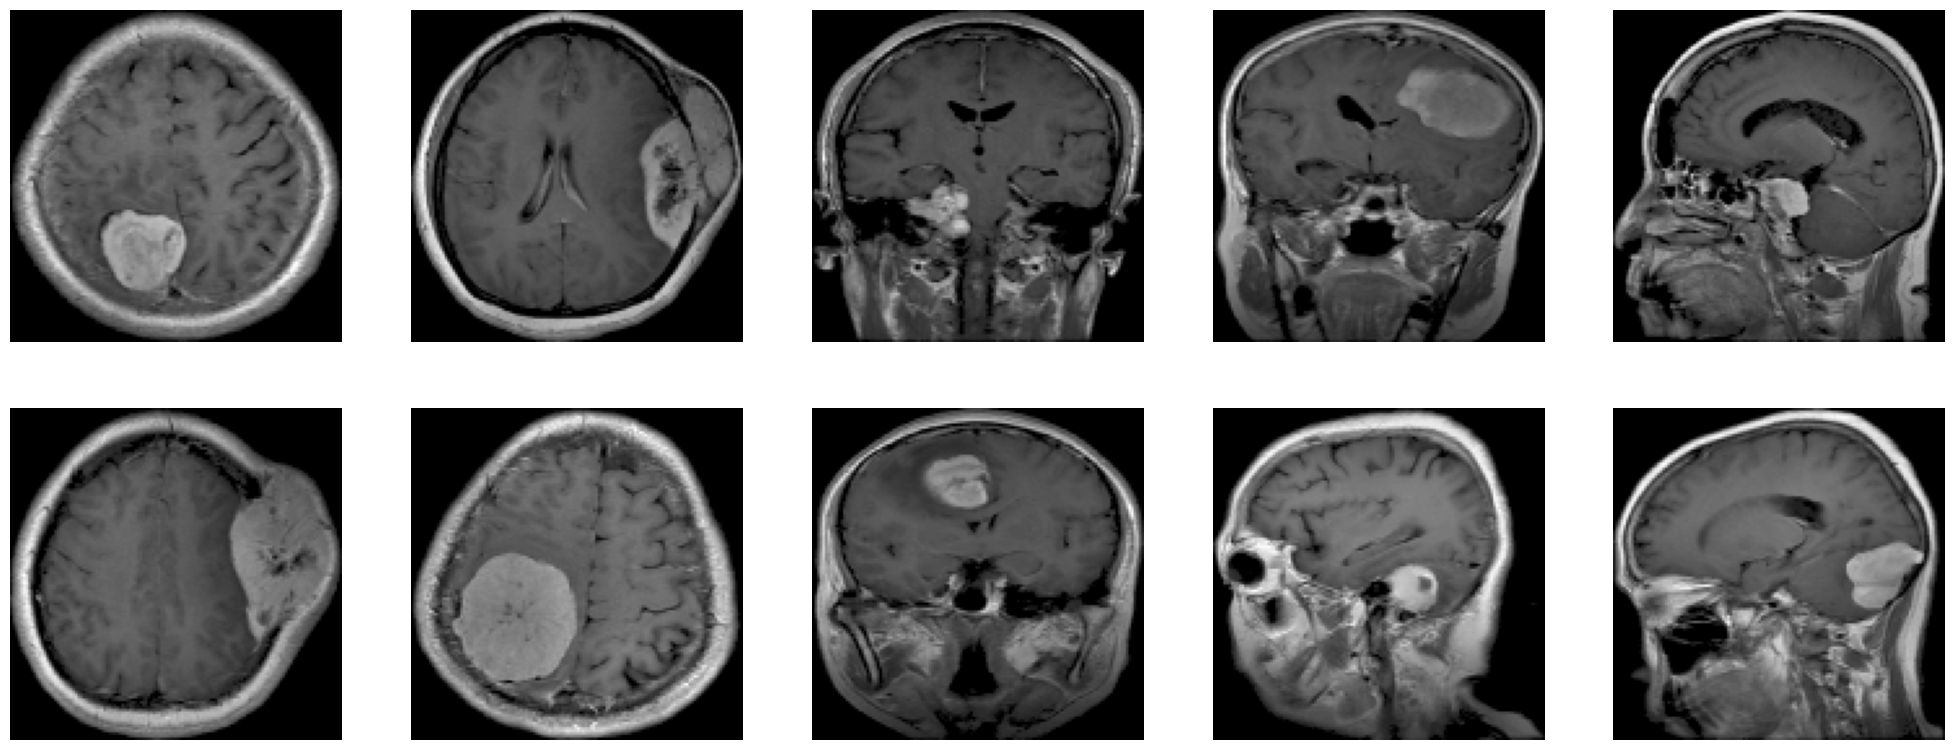

In [4]:
pyplot.figure(figsize=(25,25))
for i in range(10):
    # define subplot
    pyplot.subplot(5, 5, 1 + i)
    # turn off axis
    pyplot.axis('off')
    # plot raw pixel data
    pyplot.imshow(images[i,:,:,0],cmap='gray')
pyplot.show()


In [6]:
def define_generator():

    model = tf.keras.Sequential()

    model.add(Dense(32*32*256, input_shape=(100,)))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Reshape((32, 32,256)))

    model.add(Conv2DTranspose(256, (3,3), strides=(2,2), activation= 'relu', padding='same', use_bias=False))
    model.add(LeakyReLU(alpha=0.2))
    
    model.add(Conv2DTranspose(256, (3,3), strides=(2,2), activation= 'relu', padding='same', use_bias=False))
    model.add(LeakyReLU(alpha=0.2))


    model.add(Conv2D(CHANNEL_NUM, (3,3), activation= 'tanh', strides=(1,1), padding='same', use_bias=False))
    model.summary()
    return model

In [7]:
define_generator()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 262144)            26476544  
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 262144)            0         
                                                                 
 reshape (Reshape)           (None, 32, 32, 256)       0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 64, 64, 256)      589824    
 nspose)                                                         
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 64, 64, 256)       0         
                                                                 
 conv2d_transpose_1 (Conv2DT  (None, 128, 128, 256)    589824    
 ranspose)                                              

In [8]:
def define_discriminator(input=(128,128,CHANNEL_NUM)):

    model = tf.keras.Sequential()
    
    model.add(Conv2D(128, (3,3), strides=(2, 2), padding='same',input_shape=input))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.2))
    
    
    model.add(Conv2D(128, (3,3), strides=(2, 2), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.2))

    model.add(Conv2D(128, (3,3), strides=(2, 2), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.2))
    
    model.add(Conv2D(128, (3,3), strides=(2, 2), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.2))
    
    model.add(Flatten())
    model.add(Dense(1, activation= 'sigmoid'))
    model.summary()
    return model


In [9]:
define_discriminator()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 64, 64, 128)       3584      
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 128)      512       
 ormalization)                                                   
                                                                 
 leaky_re_lu_3 (LeakyReLU)   (None, 64, 64, 128)       0         
                                                                 
 dropout (Dropout)           (None, 64, 64, 128)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 128)       147584    
                                                                 
 batch_normalization_1 (Batc  (None, 32, 32, 128)      512       
 hNormalization)                                      

In [10]:
G_MODEL = define_generator()

D_MODEL = define_discriminator()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 262144)            26476544  
                                                                 
 leaky_re_lu_7 (LeakyReLU)   (None, 262144)            0         
                                                                 
 reshape_1 (Reshape)         (None, 32, 32, 256)       0         
                                                                 
 conv2d_transpose_2 (Conv2DT  (None, 64, 64, 256)      589824    
 ranspose)                                                       
                                                                 
 leaky_re_lu_8 (LeakyReLU)   (None, 64, 64, 256)       0         
                                                                 
 conv2d_transpose_3 (Conv2DT  (None, 128, 128, 256)    589824    
 ranspose)                                            

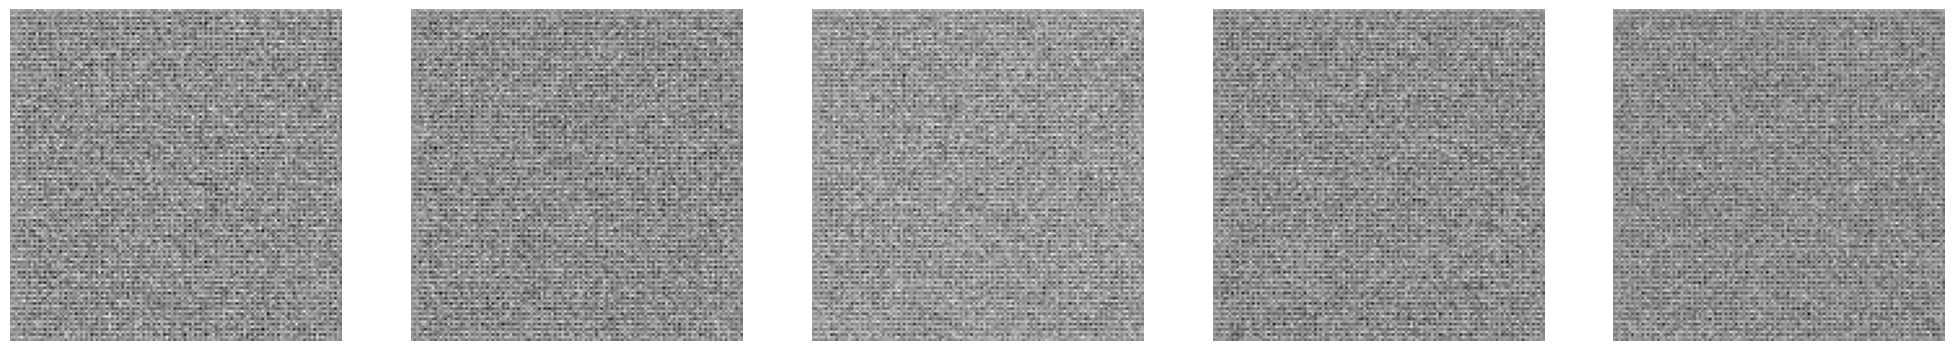

In [11]:
#generate noise according to number of samples specified with latent_dim previously defined as 256
noise = tf.random.normal([DISPLAY_SAMPLES, LATENT_DIM])

#generate fake images
x_fake = G_MODEL(noise,training=False)
pyplot.figure(figsize=(25,25))
for i in range(DISPLAY_SAMPLES):
    # define subplot
    pyplot.subplot(5, 5, 1 + i)
    pyplot.axis('off')
    # plot single image
    pyplot.imshow(x_fake[i, :, :,0],cmap='gray')
pyplot.show()
pyplot.close()


In [12]:
#Define loss functions
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss, fake_loss, real_loss
/
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [13]:
#Define optimisers

generator_optimizer = tf.keras.optimizers.Adam(G_LEARNING_RATE, G_DECAY)

discriminator_optimizer = tf.keras.optimizers.Adam(D_LEARNING_RATE, D_DECAY)

In [14]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=G_MODEL,
                                 discriminator=D_MODEL)

# Training Function

In [15]:

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = G_MODEL(noise, training=True)

        real_output = D_MODEL(images, training=True)
        fake_output = D_MODEL(generated_images, training=True)

        g_loss = generator_loss(fake_output)
        d_loss, fake_loss, real_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(g_loss, G_MODEL.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(d_loss, D_MODEL.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, G_MODEL.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, D_MODEL.trainable_variables))
    return d_loss, g_loss, fake_loss, real_loss

In [16]:
#Define training loop

BATCH_PER_EPOCH=np.round(images.shape[0]/BATCH_SIZE)

total_size=images.shape[0]

# Batch and shuffle the data
train_dataset = tf.data.Dataset.from_tensor_slices(images).shuffle(total_size).batch(BATCH_SIZE)


In [17]:
from matplotlib import pyplot as plt

def plot_learning_curve(epoch, d_loss_lst, gan_loss_lst, real, fake):
  fig = plt.figure()
  plt.plot(d_loss_lst, color='skyblue')
  plt.plot(gan_loss_lst, color='gold')
  plt.plot(real, color='green')
  plt.plot(fake, color='red')
  plt.title('Model Learning Curve')
  plt.xlabel('Epochs'); plt.ylabel('Cross Entropy Loss')
  plt.savefig(f'/kaggle/working/Learning Curves_{epoch}.png')

  plt.show()
  

# Training Loop

In [18]:
def train(dataset, epochs):
    d_hist = []
    g_hist = []
    real_hist = []
    fake_hist = []
    for epoch in range(epochs):
        count=0
        for image_batch in dataset:
            d_loss,g_loss, fake_loss, real_loss=train_step(image_batch)
            d_hist.append(d_loss)
            g_hist.append(g_loss)
            fake_hist.append(fake_loss)
            real_hist.append(real_loss)
            if (count) % 25 == 0:
                print('>%d, %d/%d, d=%.8f, g=%.8f' % (epoch, count, BATCH_PER_EPOCH, d_loss, g_loss))
            if ((count) % 250 == 0) or (epoch == 1999) or (epoch == 4999):
                noise = tf.random.normal([DISPLAY_SAMPLES, LATENT_DIM])
                x_fake = G_MODEL(noise,training=False)
                pyplot.figure(figsize=(25,25))
                if epoch % 100 ==0:
                    for i in range(DISPLAY_SAMPLES):
                        # define subplot
                        pyplot.subplot(5, 5, 1 + i)
                        pyplot.axis('off')
                        # plot single image
    #                     pyplot.imshow(x_fake[i, :, :,0],cmap='gray')

                    pyplot.savefig('/kaggle/working/Epoch_{}.png'.format(epoch))
                    plot_learning_curve(epoch, d_hist, g_hist, real_hist, fake_hist) 
#                     pyplot.show()
                    pyplot.close()
            count=count+1
            
        if epoch == 4000 or epoch == 40 or epoch == 1000 or epoch == 2000 or epoch == 3000 or epoch == 3500 or epoch == 2500:
            filename = '/kaggle/working/generator_model_' + str(epoch) + '.h5'
            G_MODEL.save(filename)
            print("Model Saved!")
    return d_hist,g_hist, fake_hist, real_hist, G_MODEL

/opt/conda/lib/python3.7/site-packages/keras/backend.py:5677: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits, "Sigmoid", "binary_crossentropy"
2023-03-11 22:52:35.159986: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_3/dropout_4/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


>0, 0/38, d=1.63018203, g=0.89773226


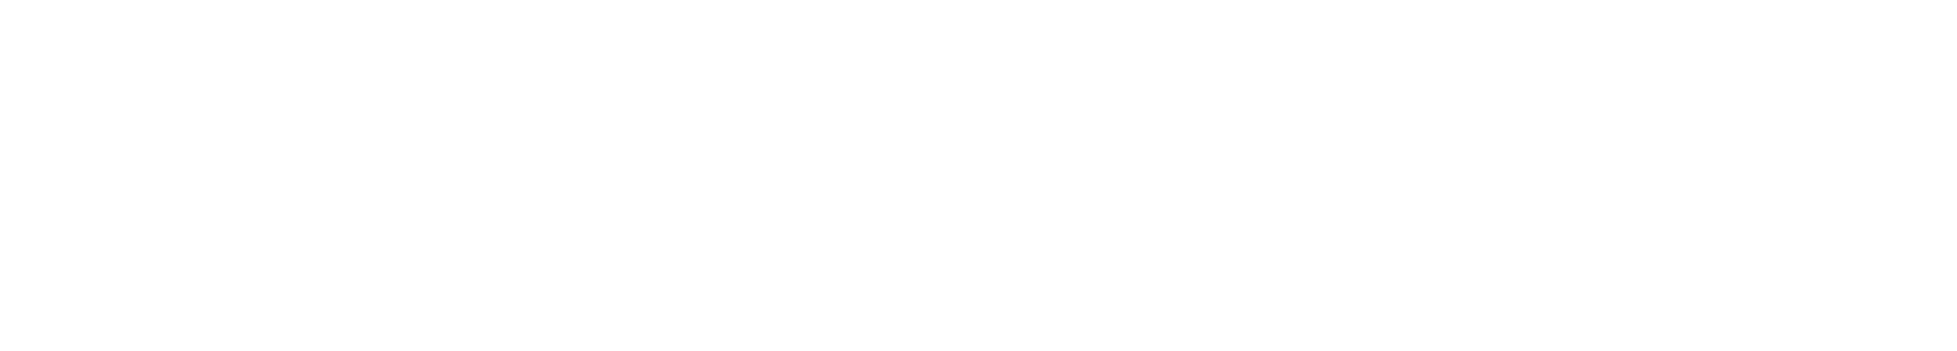

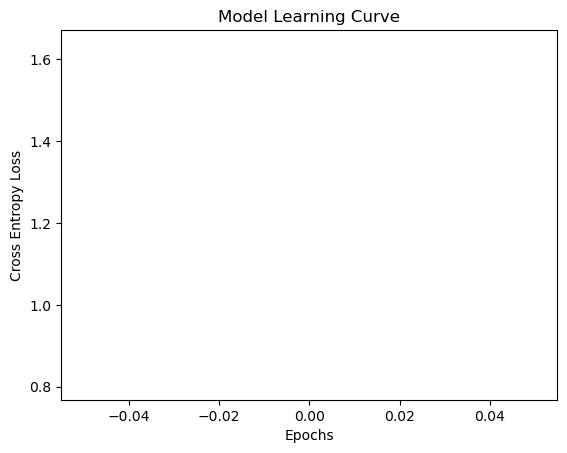

>0, 25/38, d=5.69132662, g=0.03884371


2023-03-11 22:52:43.945345: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_3/dropout_4/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


>1, 0/38, d=4.19304752, g=0.09741481
>1, 25/38, d=3.35698605, g=0.55672836
>2, 0/38, d=1.86818862, g=0.72634828
>2, 25/38, d=0.64613557, g=1.80906725
>3, 0/38, d=0.36960262, g=2.13556147
>3, 25/38, d=0.28764775, g=4.69270992
>4, 0/38, d=0.12561765, g=4.24460793
>4, 25/38, d=0.28747898, g=4.03006077
>5, 0/38, d=0.27266878, g=5.89056063
>5, 25/38, d=0.21353363, g=3.96910000
>6, 0/38, d=0.09351918, g=3.07348847
>6, 25/38, d=0.17236018, g=4.90820026
>7, 0/38, d=0.02301452, g=4.94187355
>7, 25/38, d=0.16370417, g=4.14313221
>8, 0/38, d=0.03581100, g=5.33621931
>8, 25/38, d=0.05184257, g=4.32435751
>9, 0/38, d=0.00927911, g=6.04433727
>9, 25/38, d=0.03407482, g=5.36409998
>10, 0/38, d=0.05006331, g=3.96586013
>10, 25/38, d=0.98475474, g=4.68820524
>11, 0/38, d=0.17691420, g=7.03049421
>11, 25/38, d=1.05135965, g=0.97742832
>12, 0/38, d=0.95791680, g=1.56045401
>12, 25/38, d=0.87693822, g=1.92902076
>13, 0/38, d=1.05019927, g=0.98617530
>13, 25/38, d=0.88266546, g=1.93365240
>14, 0/38, d=1.15

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).


>21, 25/38, d=0.67718083, g=1.29459238
>22, 0/38, d=0.57420033, g=1.42189384
>22, 25/38, d=0.42255139, g=2.74925709
>23, 0/38, d=1.12049150, g=0.84419668
>23, 25/38, d=0.69242579, g=2.34959531
>24, 0/38, d=0.97925621, g=0.88796753
>24, 25/38, d=0.64332819, g=1.65527177
>25, 0/38, d=0.68432015, g=2.83869457
>25, 25/38, d=0.70982051, g=1.41513300
>26, 0/38, d=0.82604414, g=0.89830345
>26, 25/38, d=0.65205479, g=1.70681322
>27, 0/38, d=0.86999148, g=1.59164381
>27, 25/38, d=0.66593516, g=1.74623132
>28, 0/38, d=0.93727010, g=0.88596344
>28, 25/38, d=0.67938364, g=2.67612362
>29, 0/38, d=0.69831169, g=2.23954511
>29, 25/38, d=1.21166241, g=1.41016066
>30, 0/38, d=1.08595538, g=1.85562158
>30, 25/38, d=1.19269180, g=1.20489585
>31, 0/38, d=0.98852372, g=0.92314184
>31, 25/38, d=1.10726929, g=1.24982452
>32, 0/38, d=0.98552704, g=1.12307644
>32, 25/38, d=1.14339614, g=1.99012756
>33, 0/38, d=1.31557035, g=2.17775297
>33, 25/38, d=1.05642319, g=1.50517416
>34, 0/38, d=0.82986248, g=1.33536077

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

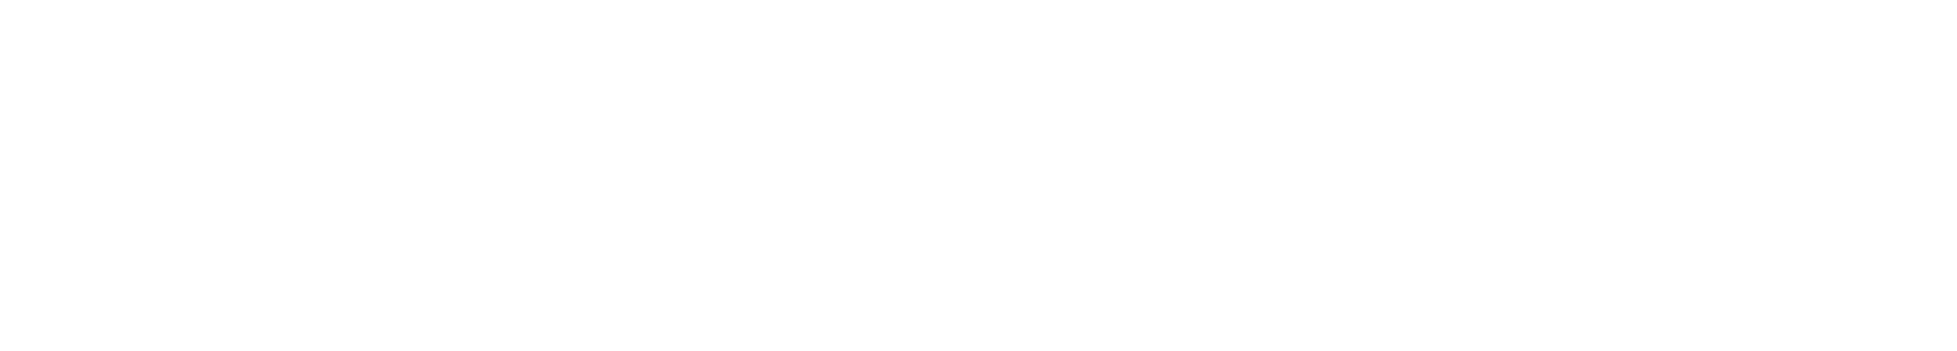

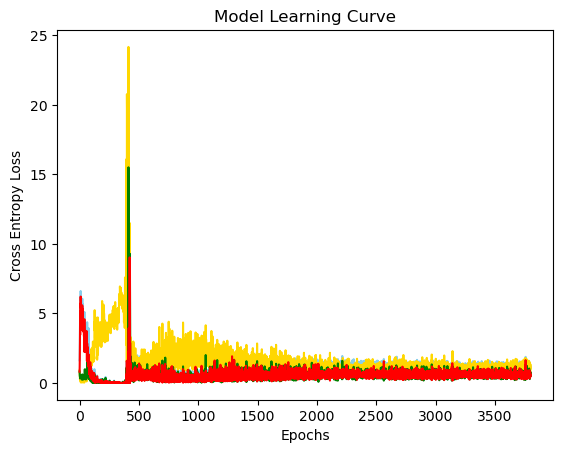

>100, 25/38, d=1.16790652, g=0.84102178
>101, 0/38, d=0.98252648, g=0.73086768
>101, 25/38, d=1.11743927, g=0.97335255
>102, 0/38, d=1.07599783, g=1.44106066
>102, 25/38, d=1.28167224, g=0.85100943
>103, 0/38, d=1.26725316, g=1.12329388
>103, 25/38, d=1.25446963, g=1.07054758
>104, 0/38, d=0.99950147, g=0.94925320
>104, 25/38, d=0.90844858, g=1.16547036
>105, 0/38, d=1.03707552, g=1.02574134
>105, 25/38, d=1.07363582, g=1.28299057
>106, 0/38, d=1.17660081, g=0.81146359
>106, 25/38, d=1.45347583, g=1.12539911
>107, 0/38, d=1.07840955, g=1.48601437
>107, 25/38, d=1.45050073, g=0.73433173
>108, 0/38, d=1.27708030, g=0.99780726
>108, 25/38, d=1.28261328, g=0.92412263
>109, 0/38, d=1.08892381, g=1.11210918
>109, 25/38, d=1.03790474, g=0.94384718
>110, 0/38, d=1.35537505, g=0.70343745
>110, 25/38, d=1.09047675, g=0.98728579
>111, 0/38, d=1.07411575, g=0.93618584
>111, 25/38, d=1.33399582, g=1.47131264
>112, 0/38, d=1.17342782, g=0.94558501
>112, 25/38, d=1.17572367, g=1.69854999
>113, 0/38, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

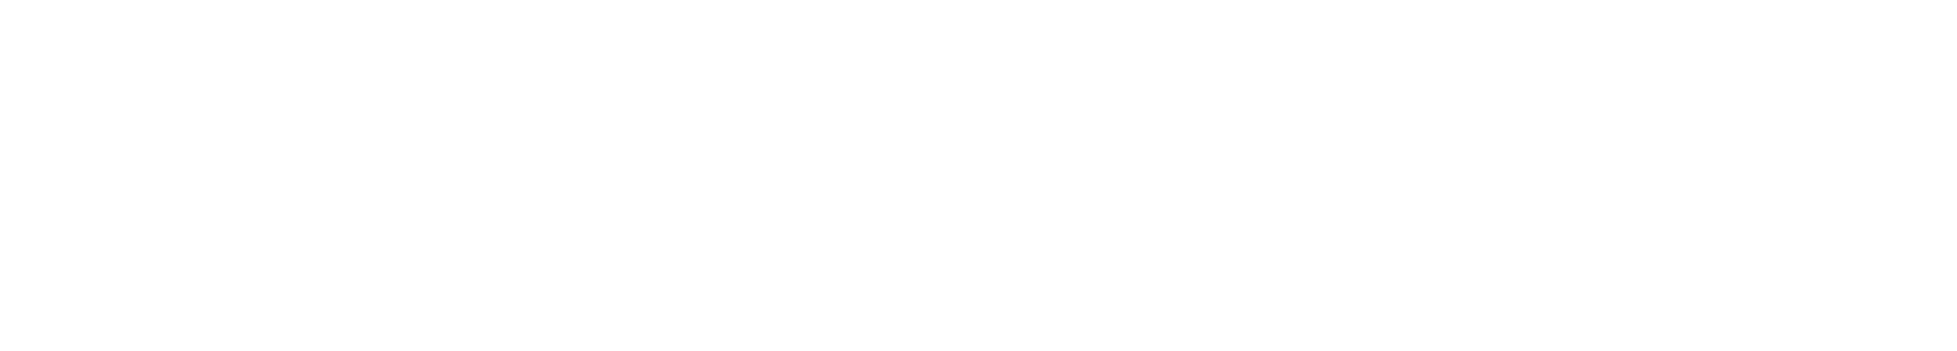

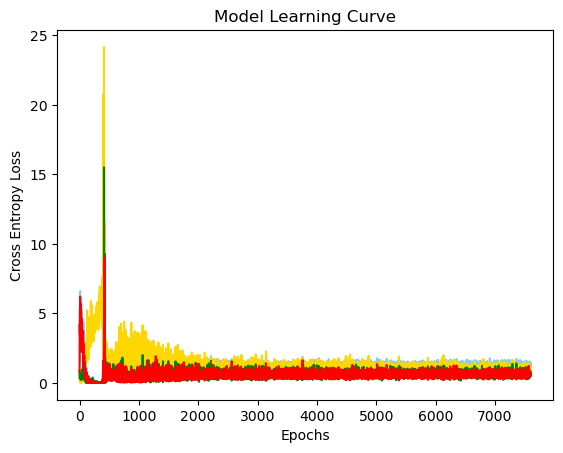

>200, 25/38, d=1.51201046, g=0.38717973
>201, 0/38, d=1.37602448, g=0.60961521
>201, 25/38, d=1.40064168, g=0.61720717
>202, 0/38, d=1.43933511, g=0.57188559
>202, 25/38, d=1.40131211, g=1.23448718
>203, 0/38, d=1.12262440, g=0.87199366
>203, 25/38, d=1.35605288, g=0.75474143
>204, 0/38, d=1.16050065, g=1.01293874
>204, 25/38, d=1.22047091, g=1.23534656
>205, 0/38, d=1.44079113, g=0.59022689
>205, 25/38, d=1.16260219, g=0.76531267
>206, 0/38, d=1.32113588, g=0.73394787
>206, 25/38, d=1.26839662, g=0.81834996
>207, 0/38, d=1.13623023, g=0.74932814
>207, 25/38, d=1.20094264, g=0.65164244
>208, 0/38, d=1.18682396, g=0.96917343
>208, 25/38, d=1.25494599, g=0.73901087
>209, 0/38, d=0.98802471, g=0.90534937
>209, 25/38, d=1.02017546, g=1.18795526
>210, 0/38, d=1.13230419, g=0.98814440
>210, 25/38, d=0.94061559, g=0.98091865
>211, 0/38, d=1.16481555, g=0.86100334
>211, 25/38, d=1.04622984, g=0.92930466
>212, 0/38, d=1.19920731, g=1.03758800
>212, 25/38, d=1.47943258, g=0.97905576
>213, 0/38, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

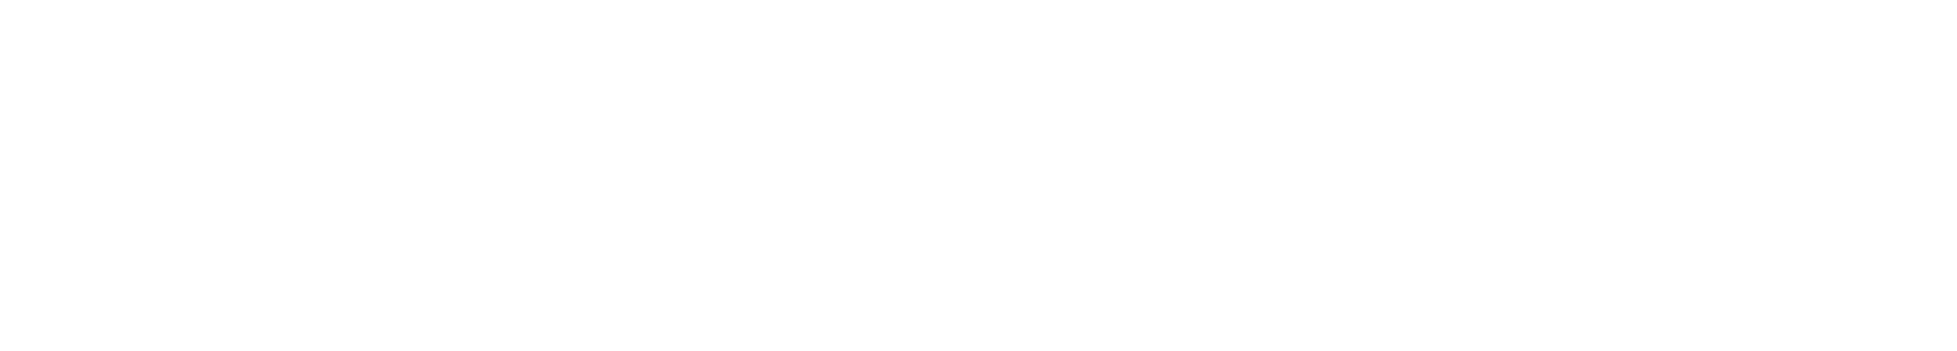

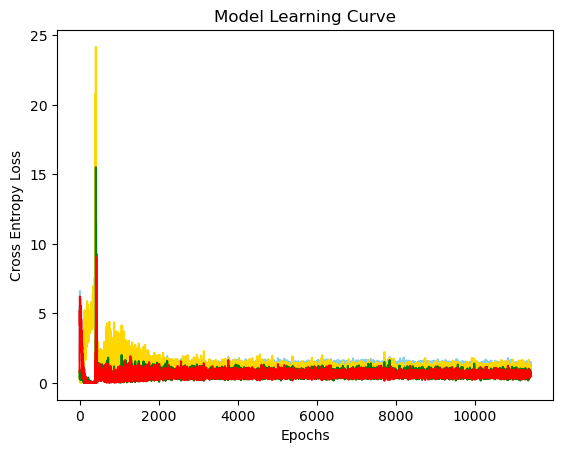

>300, 25/38, d=1.15786672, g=1.15957546
>301, 0/38, d=1.02955604, g=0.89330542
>301, 25/38, d=1.15714979, g=0.71243942
>302, 0/38, d=1.22679996, g=1.17113364
>302, 25/38, d=0.92762864, g=0.99054945
>303, 0/38, d=1.34412456, g=0.55613047
>303, 25/38, d=1.23201036, g=0.78831291
>304, 0/38, d=1.33284998, g=0.98775482
>304, 25/38, d=1.28773904, g=0.66676939
>305, 0/38, d=1.02578020, g=0.93287450
>305, 25/38, d=1.28058362, g=0.68593186
>306, 0/38, d=1.15556550, g=0.96009278
>306, 25/38, d=1.32225013, g=0.79825586
>307, 0/38, d=0.98140681, g=0.84234518
>307, 25/38, d=1.19349921, g=1.08626366
>308, 0/38, d=1.18387222, g=1.00965679
>308, 25/38, d=1.27091324, g=1.20307469
>309, 0/38, d=1.25962293, g=0.85491580
>309, 25/38, d=1.44336164, g=0.77409327
>310, 0/38, d=1.06274784, g=1.10232115
>310, 25/38, d=1.17737448, g=0.82832646
>311, 0/38, d=1.26090765, g=0.97105956
>311, 25/38, d=1.23219085, g=1.16216254
>312, 0/38, d=1.16788948, g=1.02084172
>312, 25/38, d=1.01026464, g=1.03124356
>313, 0/38, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

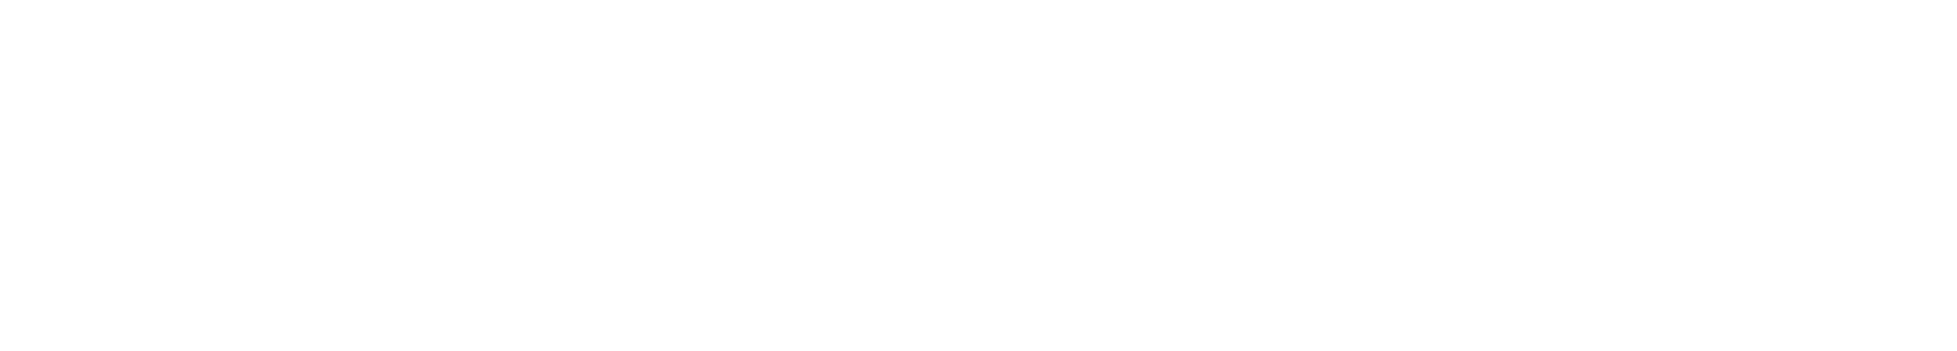

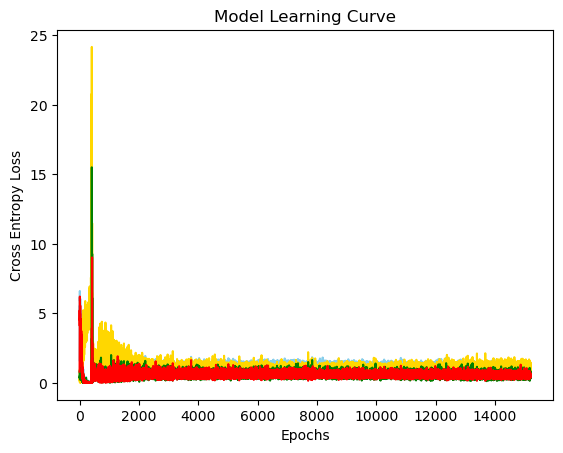

>400, 25/38, d=1.36631846, g=0.88728374
>401, 0/38, d=1.27303314, g=0.90039051
>401, 25/38, d=1.10289145, g=1.16090178
>402, 0/38, d=1.25145638, g=1.08165622
>402, 25/38, d=1.10500097, g=1.50517452
>403, 0/38, d=1.06780386, g=1.19583774
>403, 25/38, d=0.97081321, g=1.18686473
>404, 0/38, d=0.99382609, g=1.30960476
>404, 25/38, d=1.13502240, g=1.24950647
>405, 0/38, d=0.92925042, g=1.37189543
>405, 25/38, d=0.95986676, g=1.10120177
>406, 0/38, d=0.91504347, g=1.51996613
>406, 25/38, d=0.95842087, g=1.08291233
>407, 0/38, d=0.90152061, g=1.05524659
>407, 25/38, d=1.22198296, g=0.76491427
>408, 0/38, d=0.98505390, g=1.04862320
>408, 25/38, d=1.15647769, g=1.08649671
>409, 0/38, d=1.16116333, g=0.83159727
>409, 25/38, d=0.82911980, g=1.21796846
>410, 0/38, d=1.03933978, g=1.17225671
>410, 25/38, d=1.16414642, g=0.95291609
>411, 0/38, d=1.09943771, g=1.18761969
>411, 25/38, d=0.92351288, g=0.99381959
>412, 0/38, d=0.96979153, g=1.33868599
>412, 25/38, d=1.35136139, g=0.63292289
>413, 0/38, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

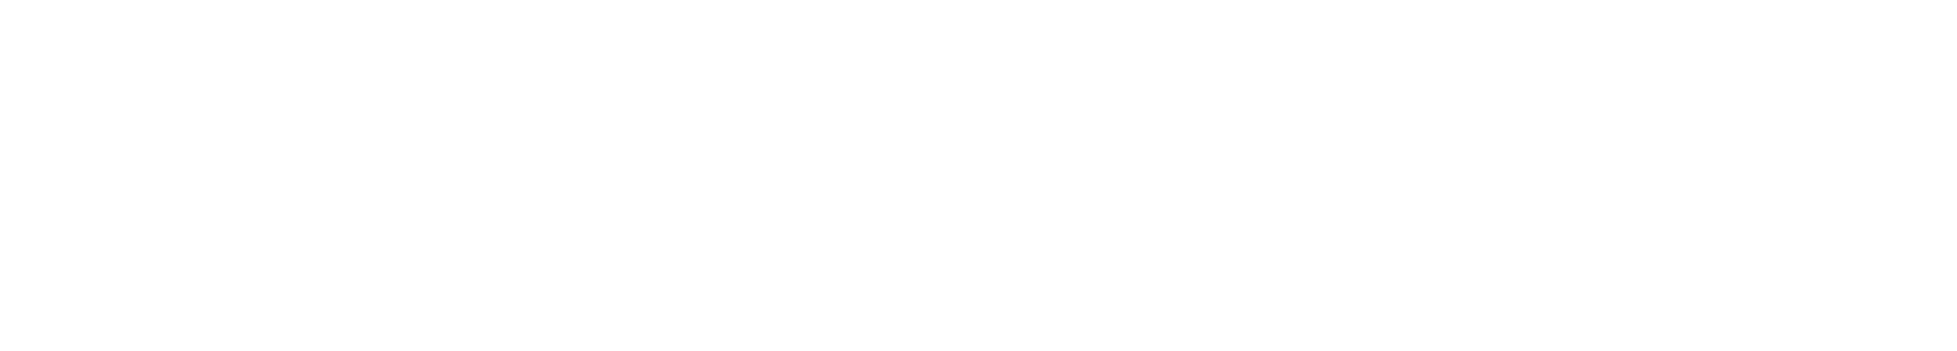

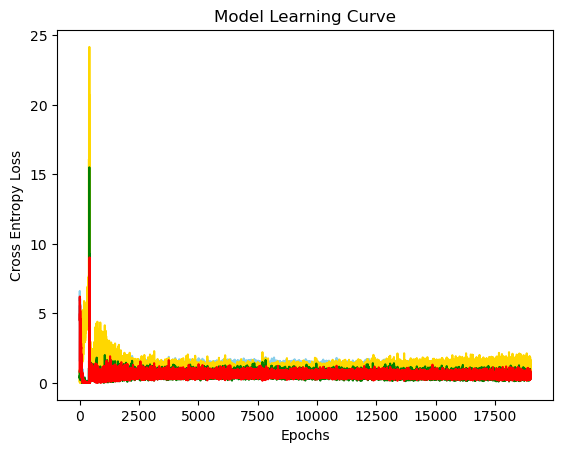

>500, 25/38, d=1.03052080, g=1.55839396
>501, 0/38, d=0.96468502, g=1.54243708
>501, 25/38, d=1.21205235, g=1.05465627
>502, 0/38, d=0.94320047, g=1.02997756
>502, 25/38, d=1.19749403, g=0.93515062
>503, 0/38, d=1.09015679, g=1.09040534
>503, 25/38, d=1.13603044, g=0.92105997
>504, 0/38, d=1.29237890, g=0.65769970
>504, 25/38, d=1.17224860, g=1.38565469
>505, 0/38, d=1.01623940, g=0.93928742
>505, 25/38, d=1.05851567, g=1.28478956
>506, 0/38, d=1.03054905, g=1.10791767
>506, 25/38, d=0.55896497, g=1.54412484
>507, 0/38, d=0.81963748, g=1.65234578
>507, 25/38, d=1.06866682, g=0.77403969
>508, 0/38, d=1.08939147, g=1.24374223
>508, 25/38, d=0.97614884, g=1.78412843
>509, 0/38, d=1.10999858, g=1.17050481
>509, 25/38, d=1.27664208, g=1.18575859
>510, 0/38, d=0.92004693, g=1.40447474
>510, 25/38, d=0.84625846, g=1.18807793
>511, 0/38, d=1.20129323, g=0.91896319
>511, 25/38, d=0.87839568, g=1.07929850
>512, 0/38, d=1.24528670, g=0.80198514
>512, 25/38, d=0.77225995, g=1.27269721
>513, 0/38, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

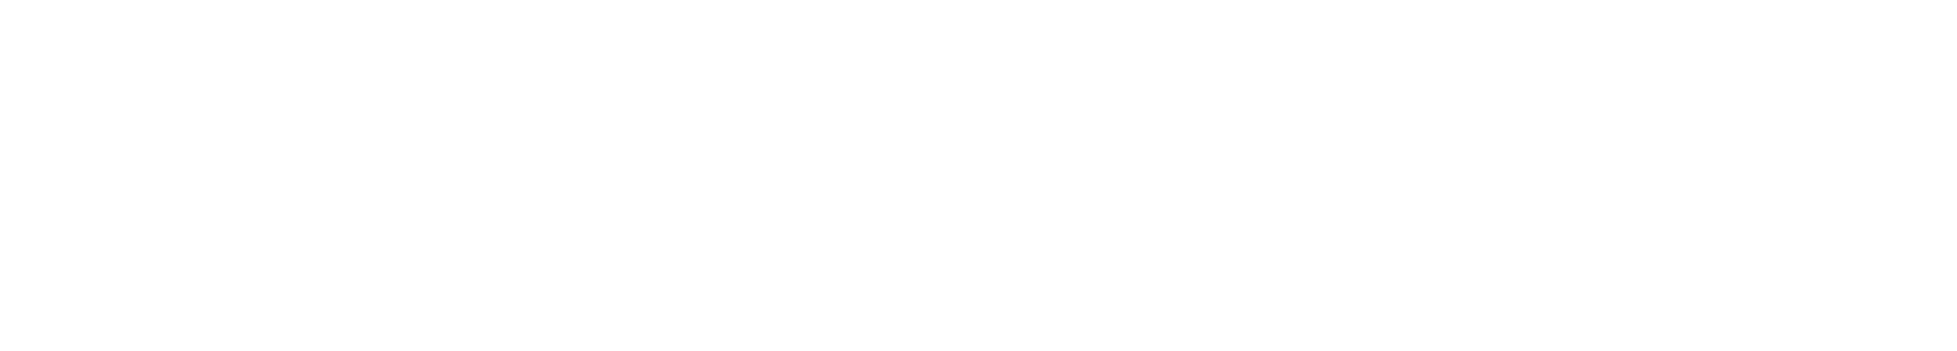

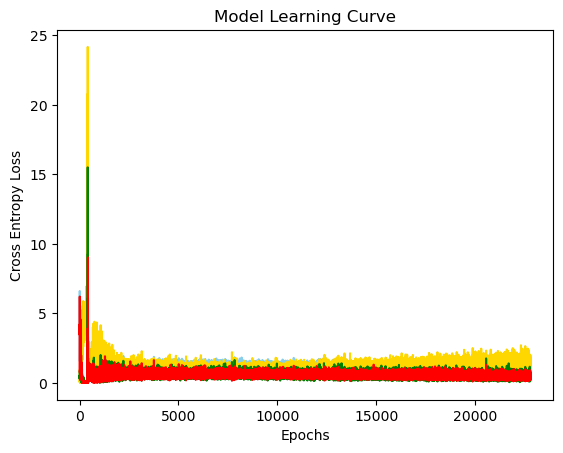

>600, 25/38, d=0.77111888, g=1.45037031
>601, 0/38, d=1.04631484, g=0.96118009
>601, 25/38, d=0.52653670, g=2.05612755
>602, 0/38, d=0.95287126, g=1.38034582
>602, 25/38, d=1.24995720, g=1.43757546
>603, 0/38, d=0.71288949, g=0.90478033
>603, 25/38, d=1.14434063, g=1.74410677
>604, 0/38, d=0.96281004, g=1.98533523
>604, 25/38, d=0.91424024, g=1.00934410
>605, 0/38, d=0.85146260, g=1.39750481
>605, 25/38, d=1.05916142, g=1.19747710
>606, 0/38, d=1.05680454, g=0.93219197
>606, 25/38, d=1.05862641, g=1.50641477
>607, 0/38, d=0.71978247, g=1.46251369
>607, 25/38, d=0.85817659, g=1.59704494
>608, 0/38, d=0.80335170, g=1.18169498
>608, 25/38, d=0.80634457, g=1.78799558
>609, 0/38, d=1.34128368, g=1.19705868
>609, 25/38, d=0.79734677, g=1.44393456
>610, 0/38, d=0.70964056, g=2.11910391
>610, 25/38, d=0.75438952, g=2.13382840
>611, 0/38, d=0.66397381, g=1.55614662
>611, 25/38, d=0.85508823, g=1.39727306
>612, 0/38, d=1.02215540, g=1.86432672
>612, 25/38, d=0.72640115, g=1.96640170
>613, 0/38, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

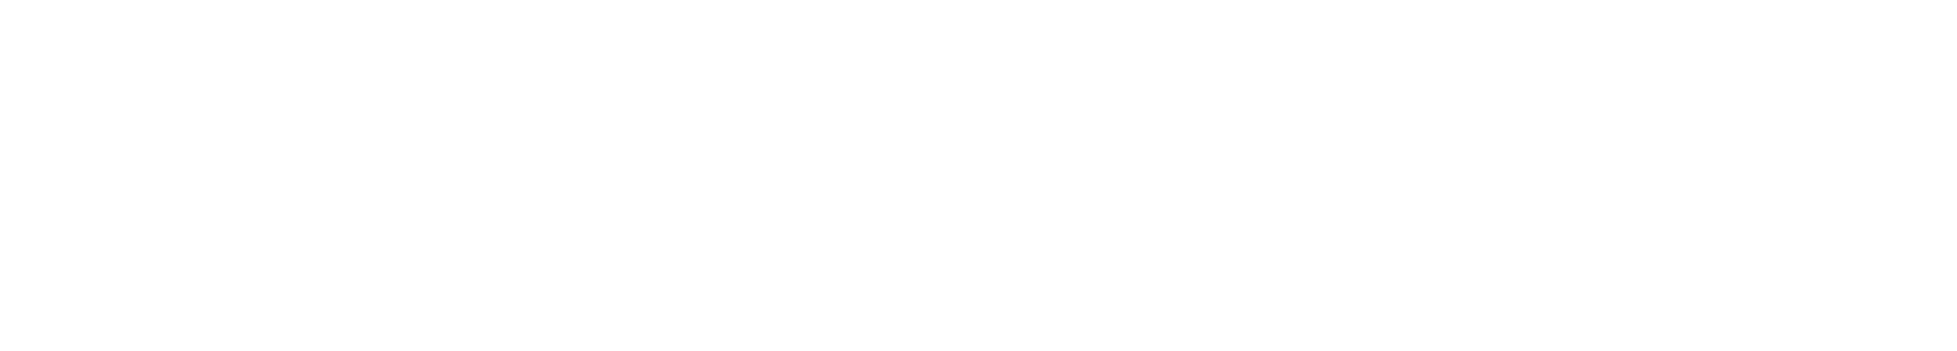

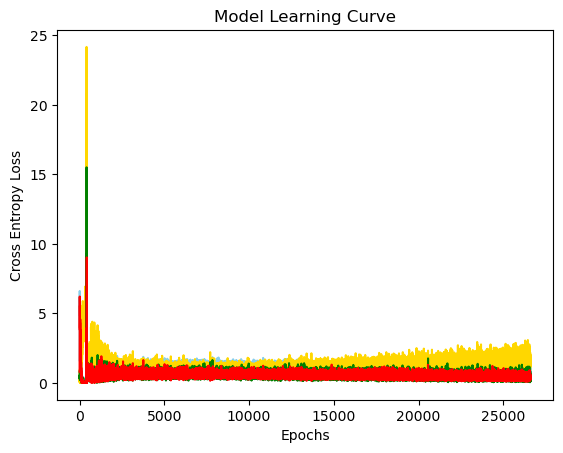

>700, 25/38, d=0.91702449, g=2.06385899
>701, 0/38, d=0.84780991, g=1.29233778
>701, 25/38, d=0.65977550, g=1.56186914
>702, 0/38, d=0.70389825, g=1.96528125
>702, 25/38, d=0.61827999, g=1.88483870
>703, 0/38, d=0.66772020, g=1.46995664
>703, 25/38, d=0.87100089, g=1.99009919
>704, 0/38, d=0.96547157, g=2.07505536
>704, 25/38, d=0.97160345, g=1.93347776
>705, 0/38, d=0.94836444, g=1.14069319
>705, 25/38, d=0.82392925, g=1.59463000
>706, 0/38, d=1.00079083, g=2.36498809
>706, 25/38, d=0.67302942, g=1.35884798
>707, 0/38, d=0.52935022, g=1.46638465
>707, 25/38, d=0.69401091, g=1.82377958
>708, 0/38, d=0.81866527, g=1.69254661
>708, 25/38, d=0.79251623, g=1.92460179
>709, 0/38, d=0.77757752, g=1.36301494
>709, 25/38, d=0.77497542, g=1.62689352
>710, 0/38, d=0.78039539, g=1.43982792
>710, 25/38, d=0.72418231, g=1.43284547
>711, 0/38, d=0.58511680, g=2.05478859
>711, 25/38, d=0.58419025, g=1.49407995
>712, 0/38, d=0.84429514, g=1.31058955
>712, 25/38, d=0.70568460, g=1.49243557
>713, 0/38, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

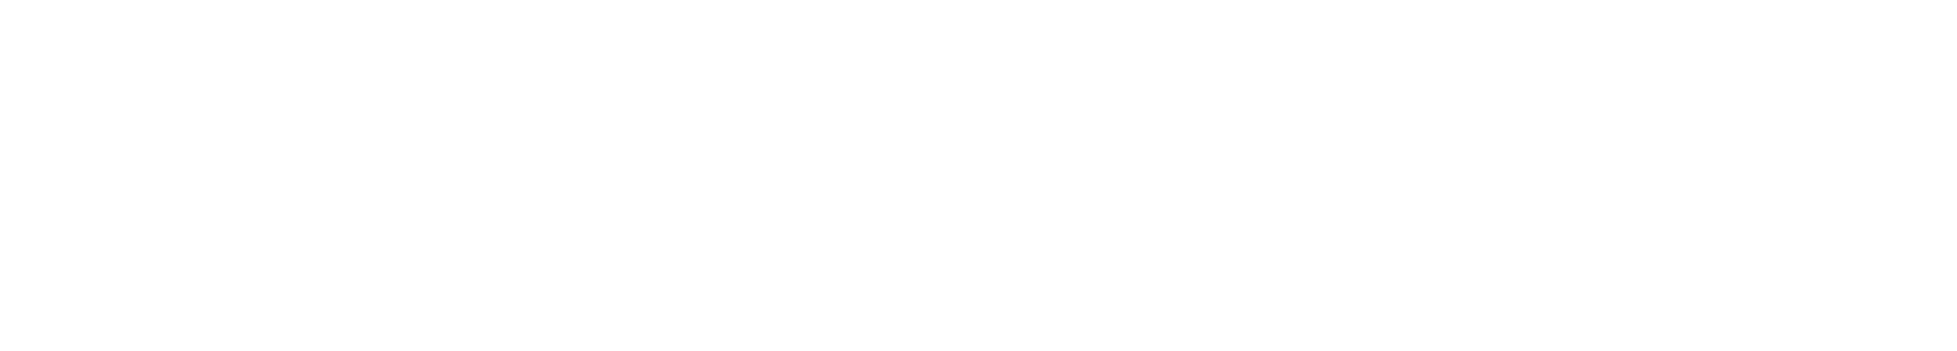

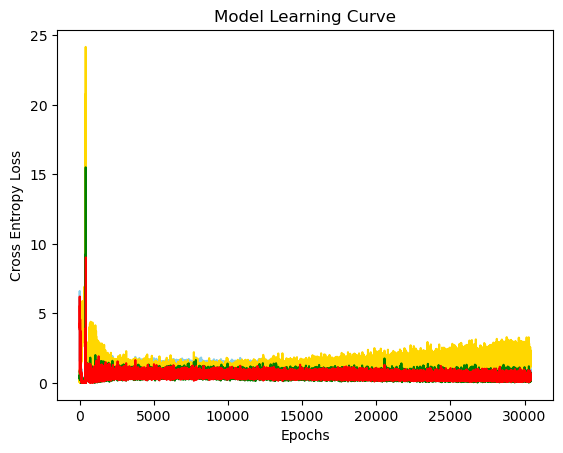

>800, 25/38, d=0.55320382, g=3.11889744
>801, 0/38, d=0.36894059, g=2.04056931
>801, 25/38, d=0.67325264, g=1.42577398
>802, 0/38, d=0.56532097, g=1.65556371
>802, 25/38, d=0.75456023, g=1.93531585
>803, 0/38, d=0.44984248, g=1.96516490
>803, 25/38, d=0.37166768, g=2.13250494
>804, 0/38, d=0.51937824, g=3.28354216
>804, 25/38, d=0.66121233, g=1.54803085
>805, 0/38, d=0.60055852, g=1.47268224
>805, 25/38, d=0.54790676, g=2.71236897
>806, 0/38, d=0.86498755, g=1.40332401
>806, 25/38, d=0.57387304, g=2.07393050
>807, 0/38, d=0.69666767, g=2.66208744
>807, 25/38, d=0.83651692, g=2.03578067
>808, 0/38, d=0.81003332, g=1.39306617
>808, 25/38, d=0.60652918, g=1.49261844
>809, 0/38, d=0.67369282, g=1.78261209
>809, 25/38, d=0.79242146, g=1.42236471
>810, 0/38, d=0.34609097, g=2.36127353
>810, 25/38, d=0.62655437, g=2.74143314
>811, 0/38, d=0.59216505, g=2.44128108
>811, 25/38, d=0.46436858, g=2.39449120
>812, 0/38, d=0.34778461, g=2.24598956
>812, 25/38, d=0.58277214, g=2.85859632
>813, 0/38, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

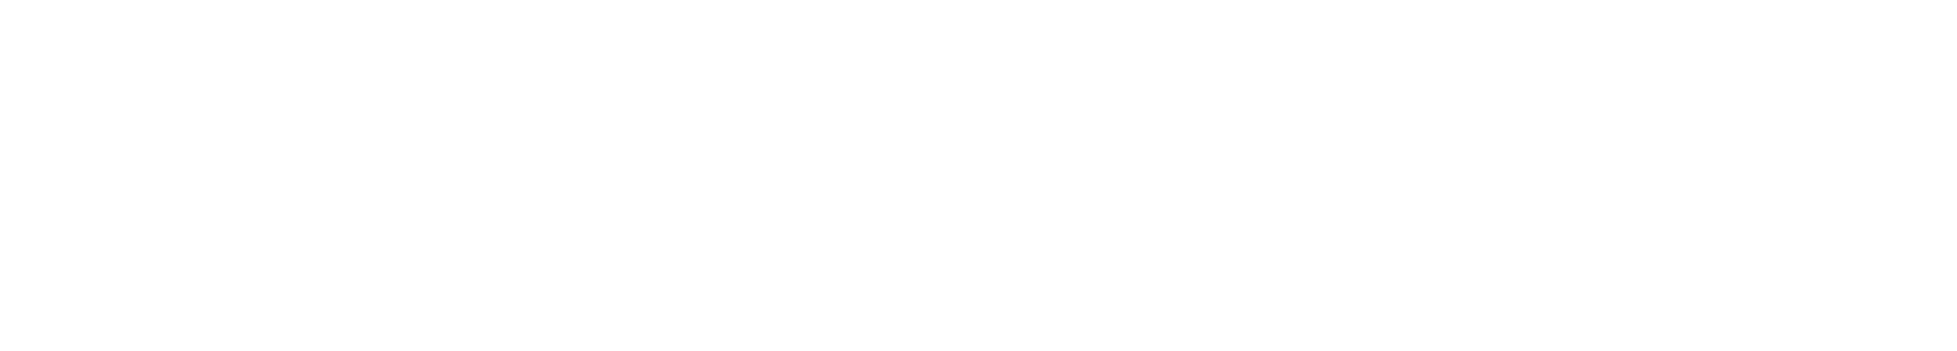

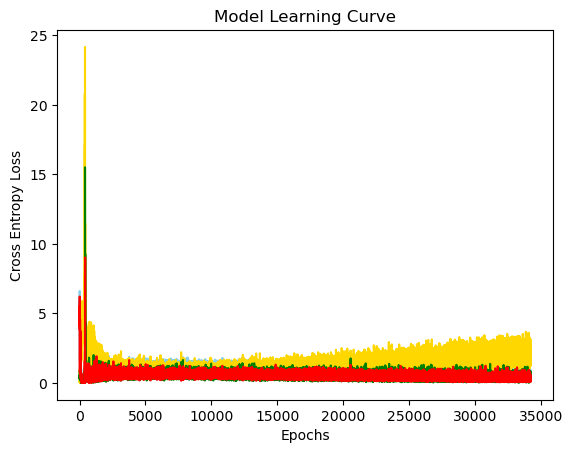

>900, 25/38, d=1.18679333, g=1.29439616
>901, 0/38, d=0.96751785, g=1.29068470
>901, 25/38, d=0.96033680, g=1.86882579
>902, 0/38, d=0.79722077, g=1.46878242
>902, 25/38, d=0.65951312, g=1.74366307
>903, 0/38, d=0.79118162, g=1.29422605
>903, 25/38, d=0.96832424, g=2.71982598
>904, 0/38, d=0.69024312, g=2.77471948
>904, 25/38, d=0.75710189, g=1.61189449
>905, 0/38, d=0.77292049, g=1.53641367
>905, 25/38, d=0.93879008, g=1.65715361
>906, 0/38, d=0.39035153, g=1.92962432
>906, 25/38, d=0.73167604, g=2.09778452
>907, 0/38, d=0.52708173, g=1.67632842
>907, 25/38, d=0.64717150, g=1.86025512
>908, 0/38, d=0.85261971, g=1.60515714
>908, 25/38, d=0.73506051, g=1.30187559
>909, 0/38, d=0.42186317, g=2.09240770
>909, 25/38, d=1.00909460, g=2.53595543
>910, 0/38, d=0.85245204, g=2.02603412
>910, 25/38, d=0.53795385, g=1.86354280
>911, 0/38, d=0.69196451, g=1.97304654
>911, 25/38, d=0.74727666, g=1.60815978
>912, 0/38, d=0.67248541, g=1.81966805
>912, 25/38, d=0.67084658, g=1.90275121
>913, 0/38, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

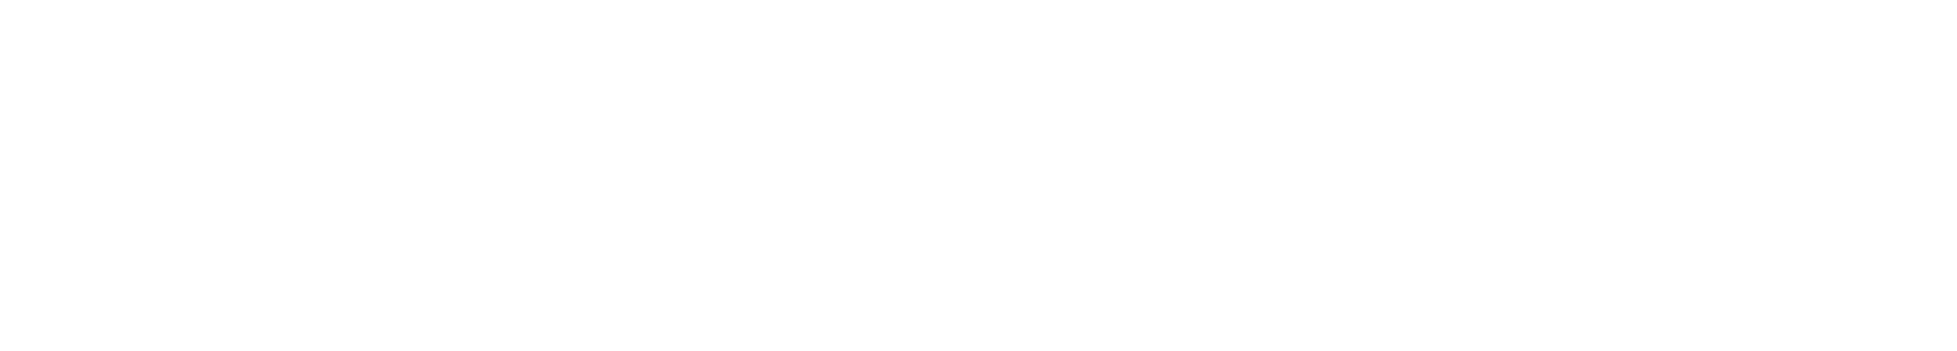

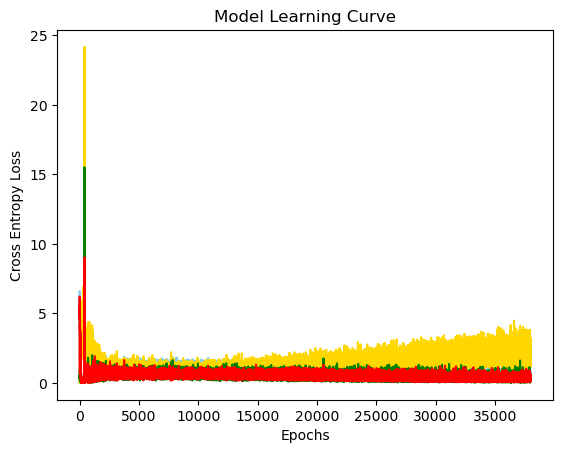

>1000, 25/38, d=0.67273283, g=2.72292423
Model Saved!
>1001, 0/38, d=0.58164591, g=2.80844784
>1001, 25/38, d=0.42024028, g=2.07113647
>1002, 0/38, d=0.37029085, g=2.71323919
>1002, 25/38, d=0.64379179, g=2.91955185
>1003, 0/38, d=0.77891946, g=3.36559916
>1003, 25/38, d=0.46021837, g=2.28092360
>1004, 0/38, d=0.40958261, g=1.81045175
>1004, 25/38, d=0.97164077, g=1.28428054
>1005, 0/38, d=0.43905869, g=2.04596424
>1005, 25/38, d=0.48274654, g=2.99847603
>1006, 0/38, d=0.88824219, g=1.29005694
>1006, 25/38, d=0.57552767, g=2.31563330
>1007, 0/38, d=0.31204456, g=2.41316128
>1007, 25/38, d=0.62616396, g=2.46488261
>1008, 0/38, d=0.65877271, g=1.70431650
>1008, 25/38, d=0.82501358, g=2.58240819
>1009, 0/38, d=0.28909415, g=2.78911066
>1009, 25/38, d=0.97817969, g=2.36301422
>1010, 0/38, d=1.08317447, g=2.00718307
>1010, 25/38, d=0.77491492, g=2.20497751
>1011, 0/38, d=0.68061858, g=1.83890796
>1011, 25/38, d=0.87177157, g=2.79263592
>1012, 0/38, d=0.54150909, g=3.30702114
>1012, 25/38, d

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

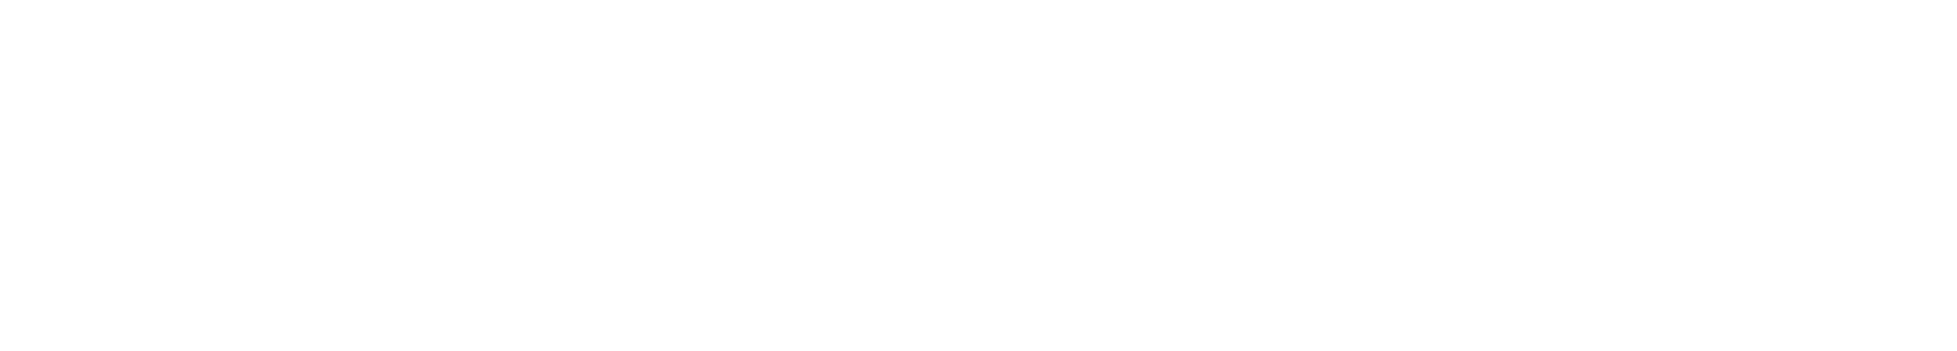

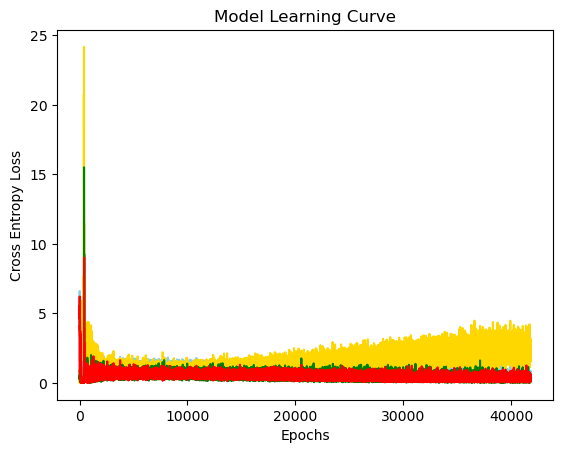

>1100, 25/38, d=0.31261817, g=2.63050771
>1101, 0/38, d=0.47335953, g=3.13632178
>1101, 25/38, d=0.82252669, g=2.67665577
>1102, 0/38, d=0.65009284, g=2.99248981
>1102, 25/38, d=0.49005151, g=2.13797164
>1103, 0/38, d=0.56552410, g=2.61849785
>1103, 25/38, d=0.34607354, g=2.05581880
>1104, 0/38, d=0.53316963, g=2.20785952
>1104, 25/38, d=0.48878321, g=2.93674946
>1105, 0/38, d=0.50761491, g=2.37641072
>1105, 25/38, d=0.61449599, g=1.88737869
>1106, 0/38, d=0.59331906, g=2.42355108
>1106, 25/38, d=0.38763553, g=2.90215516
>1107, 0/38, d=0.64210570, g=2.90706301
>1107, 25/38, d=0.47307801, g=2.68434930
>1108, 0/38, d=0.36919588, g=2.54324913
>1108, 25/38, d=0.61420077, g=2.59735680
>1109, 0/38, d=0.39275497, g=2.07717419
>1109, 25/38, d=0.89596516, g=2.91197300
>1110, 0/38, d=0.40755999, g=2.48839211
>1110, 25/38, d=0.63171673, g=2.53534794
>1111, 0/38, d=0.41695982, g=2.40286469
>1111, 25/38, d=0.38054419, g=2.61850405
>1112, 0/38, d=0.36489519, g=3.10536170
>1112, 25/38, d=0.73053432, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

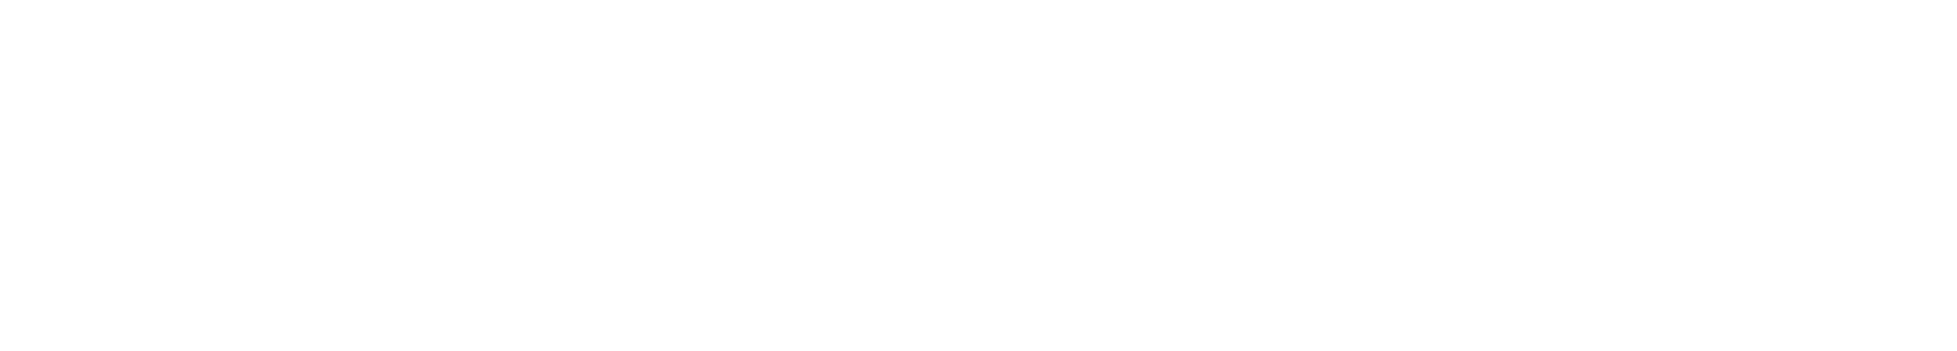

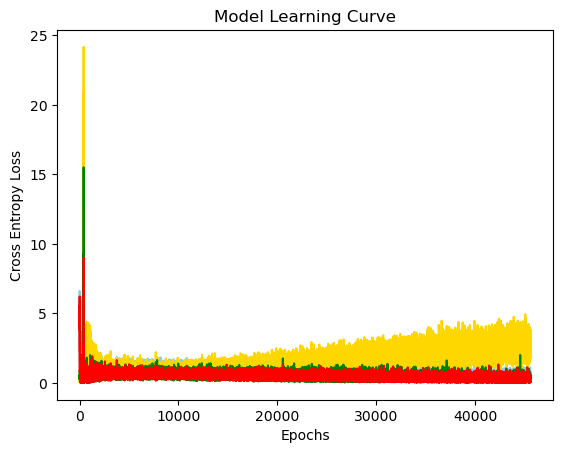

>1200, 25/38, d=0.60534382, g=2.51717162
>1201, 0/38, d=0.31712377, g=2.44976878
>1201, 25/38, d=0.42072678, g=1.90746462
>1202, 0/38, d=0.22541411, g=2.92715406
>1202, 25/38, d=0.35249761, g=2.76271152
>1203, 0/38, d=0.54554105, g=3.97785306
>1203, 25/38, d=0.82010841, g=2.83361340
>1204, 0/38, d=0.39241517, g=2.95264173
>1204, 25/38, d=0.40019017, g=2.93057823
>1205, 0/38, d=0.22367541, g=3.64766788
>1205, 25/38, d=0.42056289, g=2.73261738
>1206, 0/38, d=0.43978417, g=2.41074419
>1206, 25/38, d=0.64584523, g=2.72841263
>1207, 0/38, d=0.37956935, g=2.22438812
>1207, 25/38, d=0.14591548, g=3.16008472
>1208, 0/38, d=0.63761187, g=2.50589013
>1208, 25/38, d=0.42784435, g=2.93341732
>1209, 0/38, d=0.27059144, g=3.04509878
>1209, 25/38, d=0.58301842, g=4.00054932
>1210, 0/38, d=0.66311121, g=1.72827840
>1210, 25/38, d=0.27763069, g=2.86203790
>1211, 0/38, d=0.41256773, g=3.32891035
>1211, 25/38, d=0.54288590, g=2.01139760
>1212, 0/38, d=0.26365128, g=2.41461301
>1212, 25/38, d=0.50917304, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

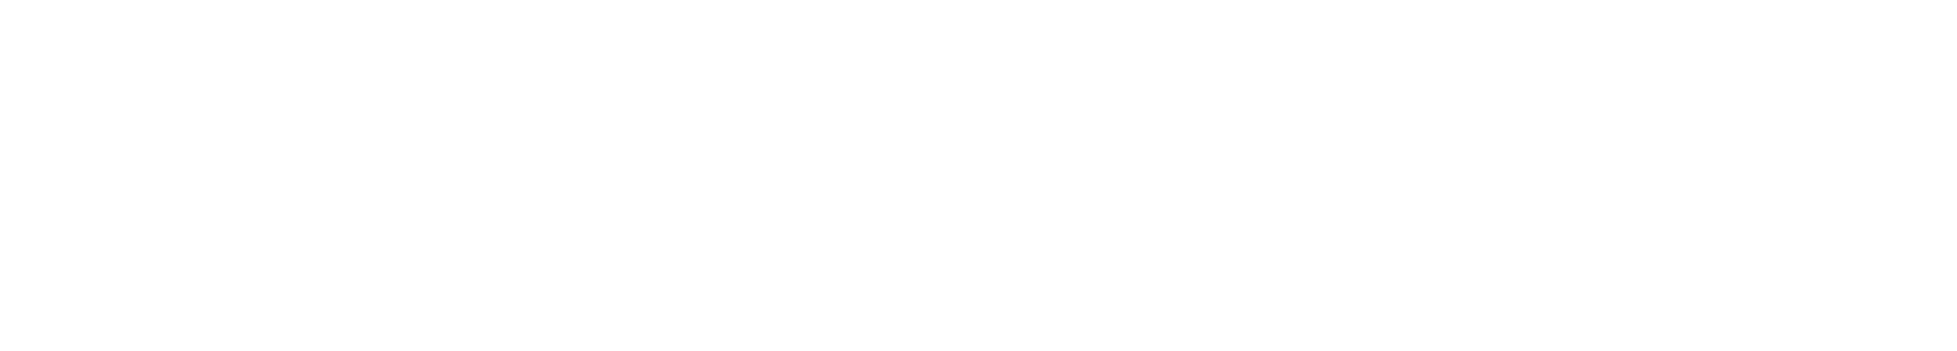

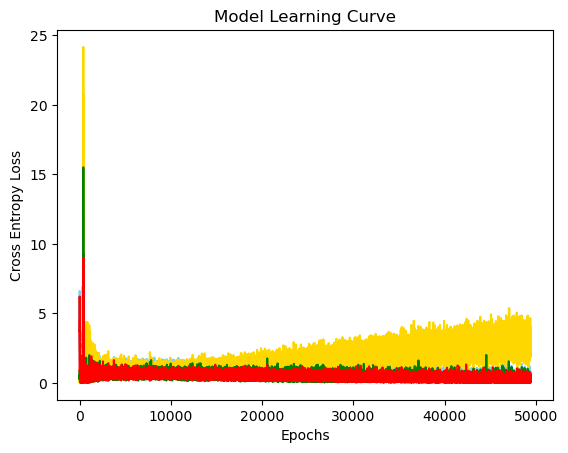

>1300, 25/38, d=0.16653131, g=2.93268013
>1301, 0/38, d=0.43388587, g=4.03363323
>1301, 25/38, d=0.59723473, g=1.81563210
>1302, 0/38, d=0.39165068, g=2.77901649
>1302, 25/38, d=0.39171267, g=3.04937172
>1303, 0/38, d=0.44008195, g=2.90779924
>1303, 25/38, d=0.56090236, g=4.19096088
>1304, 0/38, d=0.67975116, g=2.94903135
>1304, 25/38, d=0.42401445, g=3.63961649
>1305, 0/38, d=0.38025391, g=2.08116484
>1305, 25/38, d=0.40422761, g=3.43051720
>1306, 0/38, d=0.26447570, g=3.90935850
>1306, 25/38, d=0.46958855, g=2.33693218
>1307, 0/38, d=0.41991878, g=3.38258982
>1307, 25/38, d=0.49528995, g=4.16148615
>1308, 0/38, d=0.24521241, g=3.89553404
>1308, 25/38, d=0.45945650, g=2.19657326
>1309, 0/38, d=0.27514645, g=3.12126923
>1309, 25/38, d=0.30921763, g=2.35565901
>1310, 0/38, d=0.33011359, g=2.73503900
>1310, 25/38, d=0.73127753, g=2.68908739
>1311, 0/38, d=0.57606316, g=2.91311693
>1311, 25/38, d=0.62763745, g=1.95366335
>1312, 0/38, d=0.43879497, g=3.74375629
>1312, 25/38, d=0.40563458, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

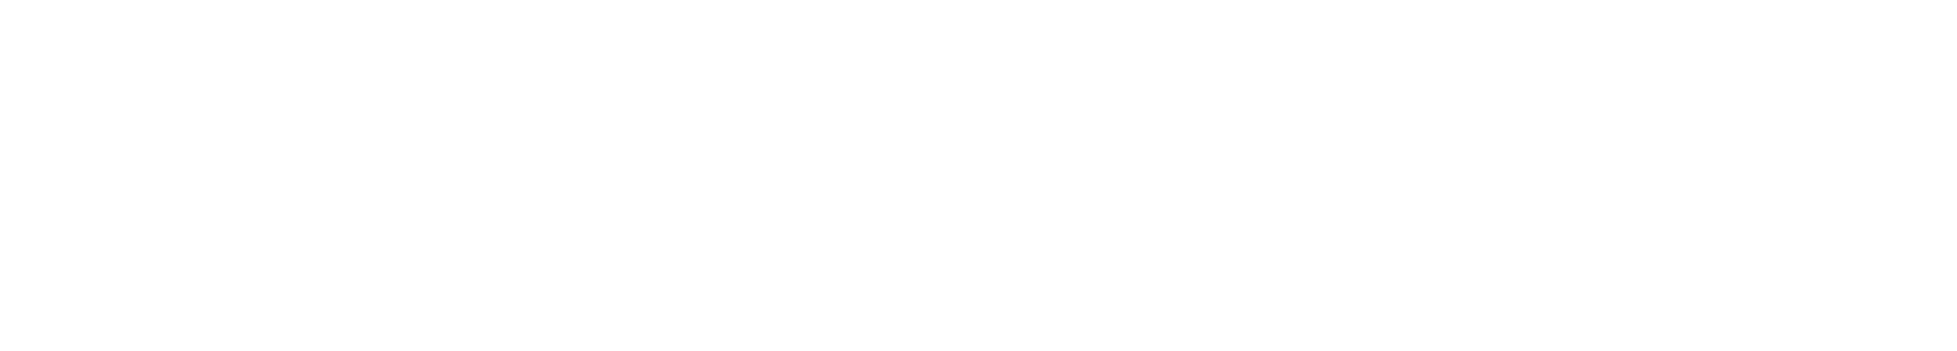

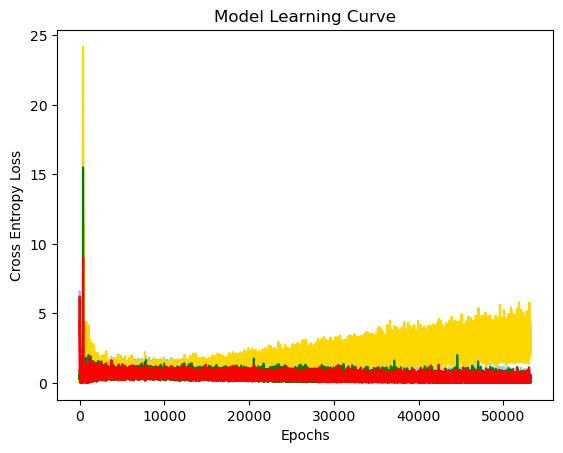

>1400, 25/38, d=0.63295853, g=4.63386106
>1401, 0/38, d=0.57683587, g=3.29651737
>1401, 25/38, d=0.36576828, g=2.07752466
>1402, 0/38, d=0.89952075, g=3.34563684
>1402, 25/38, d=0.47903070, g=3.48868656
>1403, 0/38, d=0.59371698, g=1.89266872
>1403, 25/38, d=0.32620424, g=3.64506435
>1404, 0/38, d=0.49210706, g=2.92398620
>1404, 25/38, d=0.38753065, g=3.68029380
>1405, 0/38, d=0.42673695, g=3.18872929
>1405, 25/38, d=0.18630710, g=3.58317184
>1406, 0/38, d=0.43337876, g=3.15524769
>1406, 25/38, d=0.47612238, g=2.61723089
>1407, 0/38, d=0.24814619, g=3.57851887
>1407, 25/38, d=0.26806918, g=3.95149755
>1408, 0/38, d=0.41774800, g=3.85135484
>1408, 25/38, d=0.68567359, g=1.81444240
>1409, 0/38, d=0.50403881, g=2.14883280
>1409, 25/38, d=0.29221180, g=3.32454824
>1410, 0/38, d=0.45965186, g=3.95382214
>1410, 25/38, d=0.24506895, g=3.49514365
>1411, 0/38, d=0.32724264, g=2.53537893
>1411, 25/38, d=0.72569770, g=3.85733247
>1412, 0/38, d=0.46191555, g=2.60086536
>1412, 25/38, d=0.36953527, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

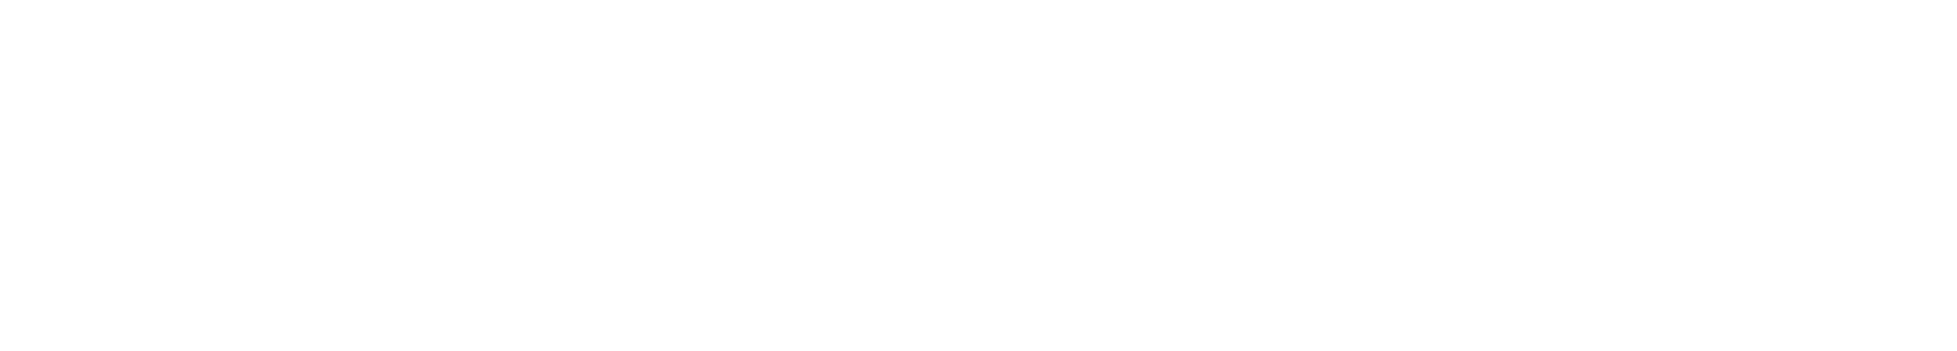

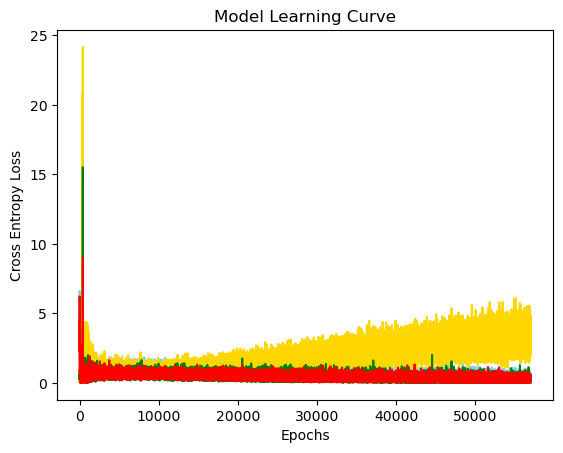

>1500, 25/38, d=0.29439312, g=3.15699434
>1501, 0/38, d=0.26020509, g=3.87719560
>1501, 25/38, d=0.24257237, g=4.62334299
>1502, 0/38, d=0.31294432, g=3.64773083
>1502, 25/38, d=0.20049231, g=4.01647186
>1503, 0/38, d=0.47916177, g=2.81522107
>1503, 25/38, d=0.14575572, g=4.08396244
>1504, 0/38, d=0.49960226, g=3.37091398
>1504, 25/38, d=0.20484249, g=3.01063347
>1505, 0/38, d=0.44020417, g=2.23755217
>1505, 25/38, d=0.67120463, g=3.03874660
>1506, 0/38, d=0.40226680, g=2.83261156
>1506, 25/38, d=0.40765202, g=2.99022603
>1507, 0/38, d=0.32901818, g=3.52007675
>1507, 25/38, d=0.50887299, g=3.35194302
>1508, 0/38, d=0.46387291, g=2.11446214
>1508, 25/38, d=0.35910243, g=3.70675802
>1509, 0/38, d=0.25451225, g=2.65983152
>1509, 25/38, d=0.22018848, g=3.83803320
>1510, 0/38, d=0.21265061, g=2.39330578
>1510, 25/38, d=0.18234880, g=2.82394981
>1511, 0/38, d=0.36858970, g=4.22201347
>1511, 25/38, d=0.23265757, g=3.89670849
>1512, 0/38, d=0.27300644, g=2.46330929
>1512, 25/38, d=0.51332641, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

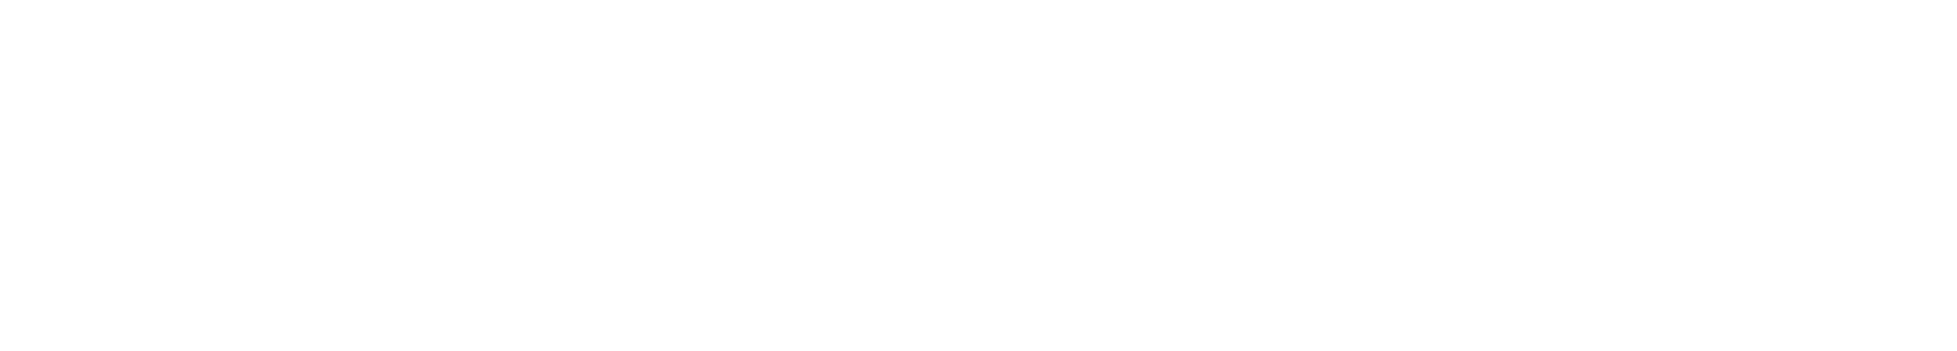

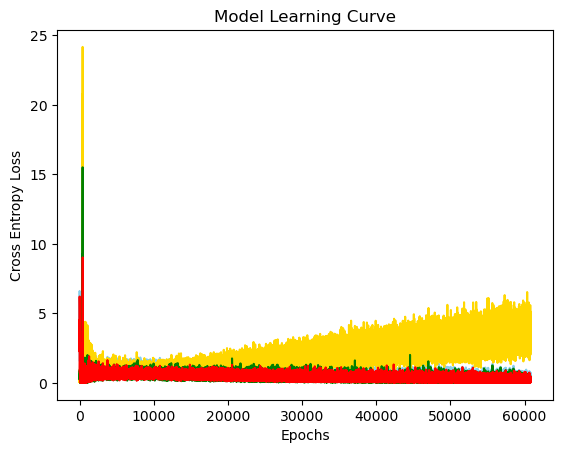

>1600, 25/38, d=0.14283970, g=5.17968321
>1601, 0/38, d=0.18938245, g=4.81677532
>1601, 25/38, d=0.42088956, g=3.47899508
>1602, 0/38, d=0.14617601, g=4.02791405
>1602, 25/38, d=0.24970563, g=3.64561439
>1603, 0/38, d=0.22899629, g=3.51304150
>1603, 25/38, d=0.20338222, g=4.71008301
>1604, 0/38, d=0.45746419, g=3.15321350
>1604, 25/38, d=0.38326013, g=3.29791284
>1605, 0/38, d=0.22284655, g=3.54263592
>1605, 25/38, d=0.25319815, g=2.92731953
>1606, 0/38, d=0.95720452, g=4.52676487
>1606, 25/38, d=0.60640663, g=3.86870003
>1607, 0/38, d=0.64150035, g=4.03194761
>1607, 25/38, d=0.34062999, g=3.90124941
>1608, 0/38, d=0.44689339, g=3.96344876
>1608, 25/38, d=0.51551068, g=3.86626315
>1609, 0/38, d=0.27034554, g=2.52062798
>1609, 25/38, d=0.38339674, g=3.05404758
>1610, 0/38, d=0.10167582, g=3.71812534
>1610, 25/38, d=0.58243024, g=2.71663189
>1611, 0/38, d=0.39141530, g=3.96698236
>1611, 25/38, d=0.42796049, g=4.50409174
>1612, 0/38, d=0.21659458, g=4.91996288
>1612, 25/38, d=0.47523850, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

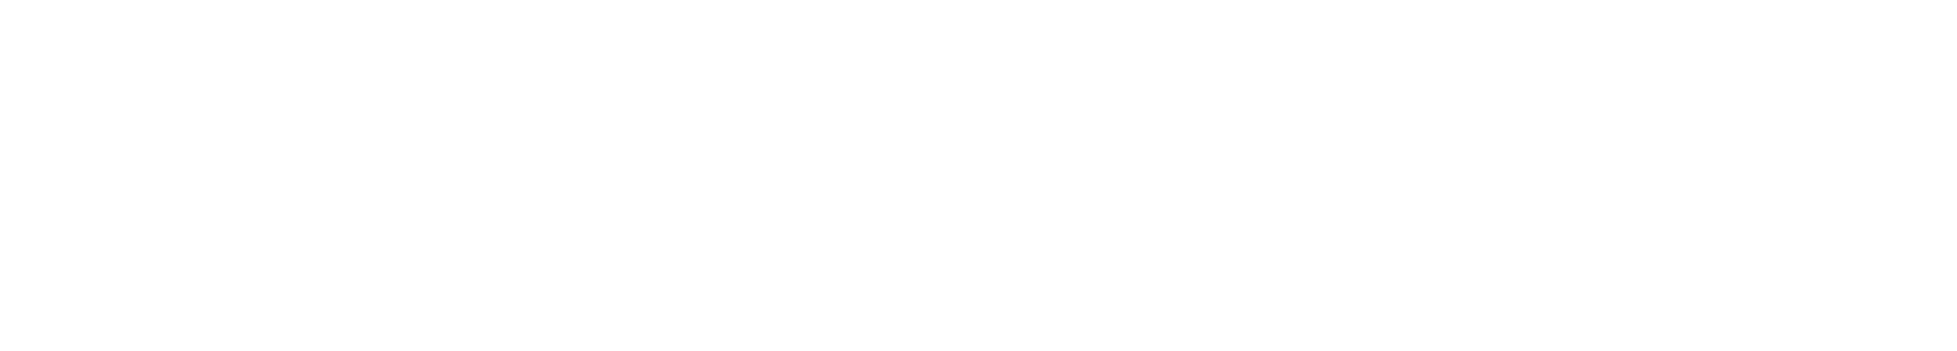

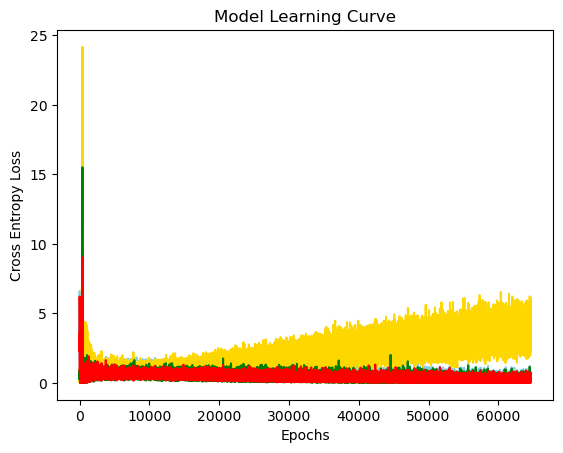

>1700, 25/38, d=0.23078559, g=3.23059225
>1701, 0/38, d=0.63946080, g=2.83539820
>1701, 25/38, d=0.45405906, g=4.58921242
>1702, 0/38, d=0.25427592, g=4.89140797
>1702, 25/38, d=0.46744868, g=3.63071513
>1703, 0/38, d=0.18272364, g=4.65581322
>1703, 25/38, d=0.69228292, g=2.98013401
>1704, 0/38, d=0.54572248, g=3.73718762
>1704, 25/38, d=0.20079128, g=4.52353001
>1705, 0/38, d=0.19887240, g=3.46963930
>1705, 25/38, d=0.78077430, g=4.02195930
>1706, 0/38, d=0.23608118, g=3.46107554
>1706, 25/38, d=0.29786372, g=3.30092406
>1707, 0/38, d=0.54021490, g=2.64849758
>1707, 25/38, d=0.06439628, g=4.24906349
>1708, 0/38, d=0.13878620, g=3.99185324
>1708, 25/38, d=0.68568826, g=3.76082778
>1709, 0/38, d=0.10899663, g=3.66607881
>1709, 25/38, d=0.59743547, g=3.06624937
>1710, 0/38, d=0.35219342, g=2.48709249
>1710, 25/38, d=0.38103554, g=3.98642588
>1711, 0/38, d=0.10622567, g=3.85819340
>1711, 25/38, d=0.17503242, g=4.17726564
>1712, 0/38, d=0.53245163, g=3.09899426
>1712, 25/38, d=0.38997382, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

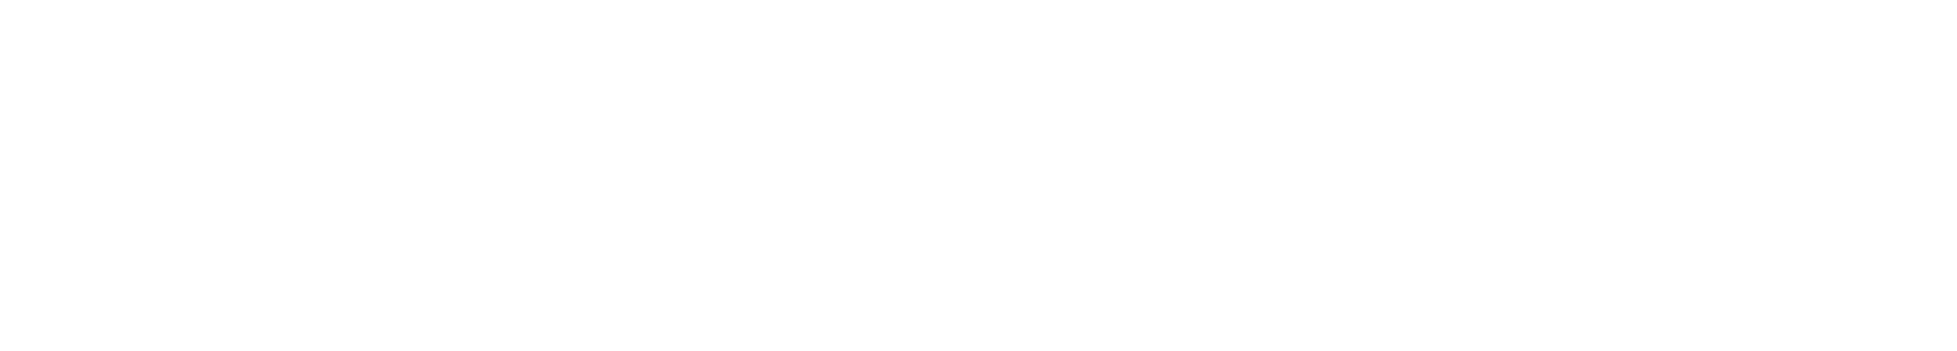

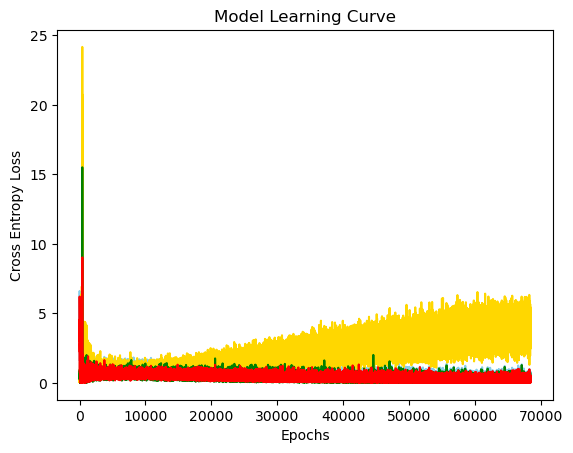

>1800, 25/38, d=0.39484194, g=5.46858883
>1801, 0/38, d=0.39924091, g=3.92101932
>1801, 25/38, d=0.43411779, g=4.99223852
>1802, 0/38, d=0.28958350, g=4.60739470
>1802, 25/38, d=0.10580750, g=4.30360126
>1803, 0/38, d=0.39594826, g=5.34436607
>1803, 25/38, d=0.27230573, g=3.24544907
>1804, 0/38, d=0.40697971, g=3.27432108
>1804, 25/38, d=0.26159626, g=3.66316891
>1805, 0/38, d=0.36894313, g=3.33532524
>1805, 25/38, d=0.17233610, g=3.91217661
>1806, 0/38, d=0.41619915, g=3.86750603
>1806, 25/38, d=0.36831644, g=2.34111738
>1807, 0/38, d=0.25826126, g=2.97530270
>1807, 25/38, d=0.39319980, g=4.24338531
>1808, 0/38, d=0.13669127, g=3.27879810
>1808, 25/38, d=0.18623888, g=4.71624041
>1809, 0/38, d=0.35905674, g=4.87897205
>1809, 25/38, d=0.27740666, g=3.36748147
>1810, 0/38, d=0.19511949, g=3.96459293
>1810, 25/38, d=0.32516757, g=4.52245712
>1811, 0/38, d=0.30615908, g=2.99624681
>1811, 25/38, d=0.33430776, g=3.45124841
>1812, 0/38, d=0.25635034, g=3.62320232
>1812, 25/38, d=0.16712318, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

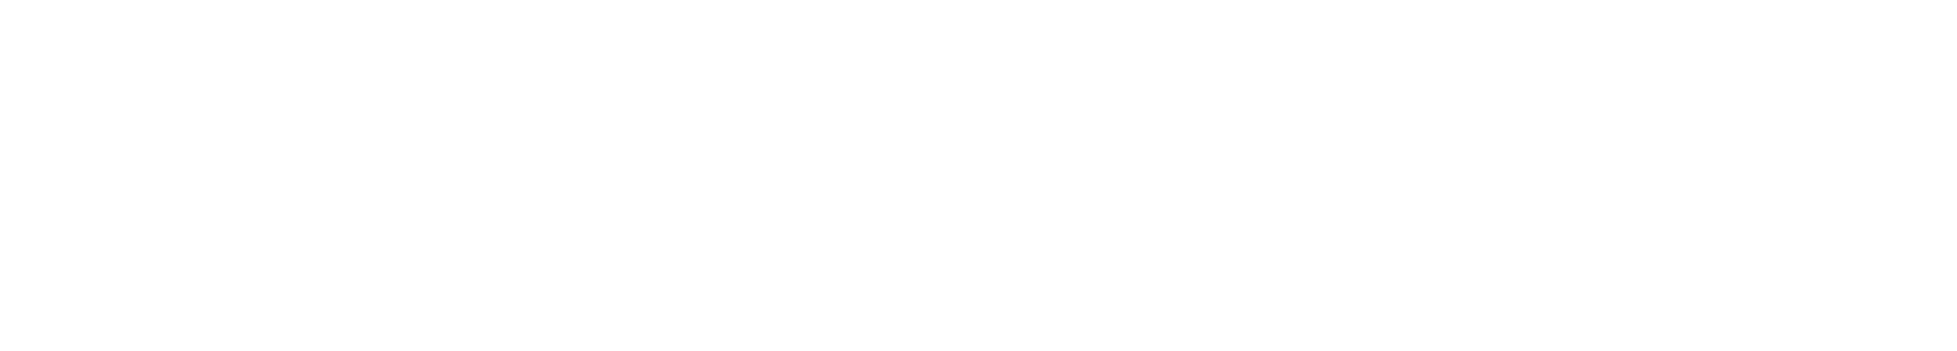

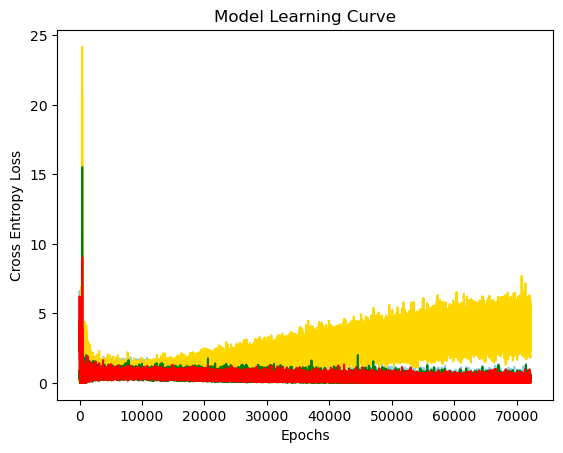

>1900, 25/38, d=0.48709050, g=2.11152291
>1901, 0/38, d=0.18995599, g=4.84214258
>1901, 25/38, d=0.11164545, g=3.69101000
>1902, 0/38, d=0.31364501, g=3.40126991
>1902, 25/38, d=0.31244037, g=4.17996693
>1903, 0/38, d=0.47043294, g=2.40312624
>1903, 25/38, d=0.38998693, g=3.82913065
>1904, 0/38, d=0.12395822, g=4.20452356
>1904, 25/38, d=0.19901365, g=4.23097897
>1905, 0/38, d=0.44867224, g=4.81163883
>1905, 25/38, d=0.42059505, g=2.71834326
>1906, 0/38, d=0.45847642, g=4.16985321
>1906, 25/38, d=0.21331105, g=3.48095894
>1907, 0/38, d=0.37256774, g=5.14176798
>1907, 25/38, d=0.10033768, g=4.79417229
>1908, 0/38, d=0.18462041, g=3.15501785
>1908, 25/38, d=0.57024658, g=4.37083340
>1909, 0/38, d=0.17575572, g=3.40620661
>1909, 25/38, d=0.17385714, g=4.01657581
>1910, 0/38, d=0.19837746, g=4.34357357
>1910, 25/38, d=0.26242673, g=3.53970194
>1911, 0/38, d=0.16711937, g=4.90681601
>1911, 25/38, d=0.15938127, g=3.86110473
>1912, 0/38, d=0.10846207, g=5.89436054
>1912, 25/38, d=0.34303850, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

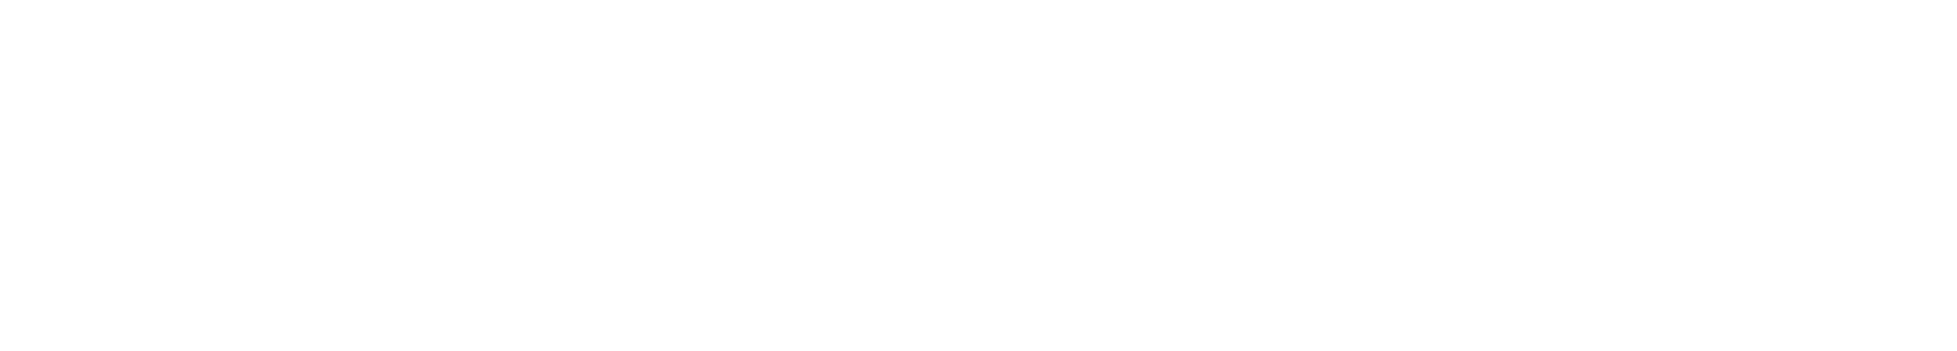

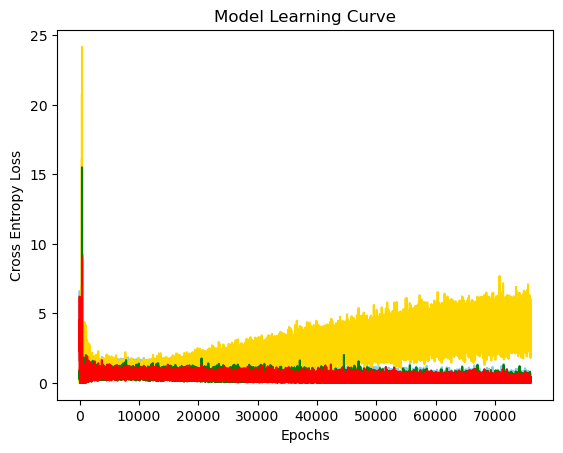

>2000, 25/38, d=0.26159856, g=4.13040924
Model Saved!
>2001, 0/38, d=0.11645486, g=4.30770588
>2001, 25/38, d=0.27178836, g=3.85026670
>2002, 0/38, d=0.37761509, g=3.09380984
>2002, 25/38, d=0.35222527, g=3.89739060
>2003, 0/38, d=0.16561410, g=5.71615791
>2003, 25/38, d=0.29655111, g=4.71125889
>2004, 0/38, d=0.20313197, g=5.53031731
>2004, 25/38, d=0.17408985, g=5.02713585
>2005, 0/38, d=0.17810133, g=4.17067719
>2005, 25/38, d=0.17738163, g=3.47264743
>2006, 0/38, d=0.19321772, g=4.96419907
>2006, 25/38, d=0.22859682, g=4.77260447
>2007, 0/38, d=0.13761470, g=3.97621226
>2007, 25/38, d=0.29749811, g=4.61917496
>2008, 0/38, d=0.26992521, g=4.03117847
>2008, 25/38, d=0.14709909, g=5.23926020
>2009, 0/38, d=0.63467449, g=3.67690325
>2009, 25/38, d=0.17774263, g=4.72590113
>2010, 0/38, d=0.10158285, g=5.74095964
>2010, 25/38, d=0.10948309, g=4.26286316
>2011, 0/38, d=0.20289110, g=3.57341433
>2011, 25/38, d=0.36484313, g=3.94678998
>2012, 0/38, d=0.17860994, g=3.86802340
>2012, 25/38, d

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

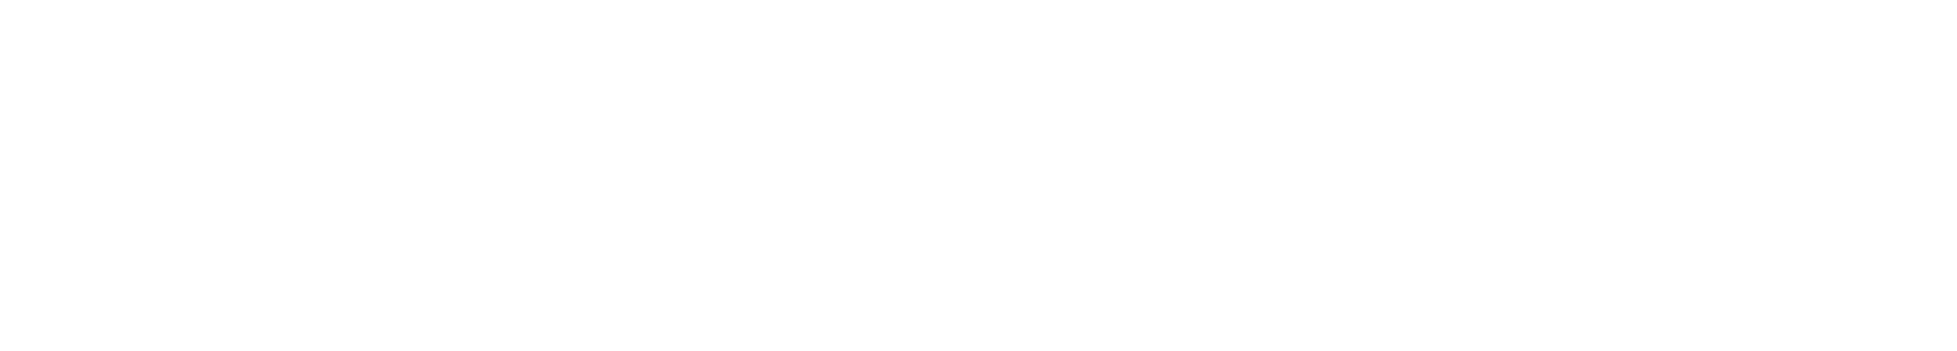

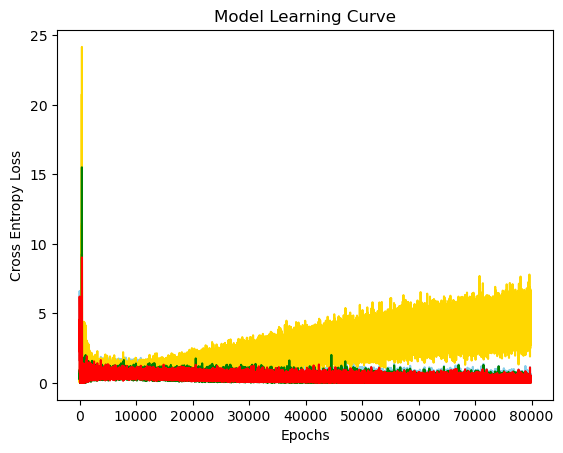

>2100, 25/38, d=0.45278937, g=3.36635923
>2101, 0/38, d=0.52795100, g=2.75796342
>2101, 25/38, d=0.09407976, g=4.34405184
>2102, 0/38, d=0.17219643, g=4.45468378
>2102, 25/38, d=0.46299040, g=3.71605301
>2103, 0/38, d=0.22023290, g=4.28029919
>2103, 25/38, d=0.11798604, g=5.00147057
>2104, 0/38, d=0.51883221, g=4.58631039
>2104, 25/38, d=0.21582612, g=4.19685555
>2105, 0/38, d=0.14319342, g=4.43667078
>2105, 25/38, d=0.22620612, g=5.74871159
>2106, 0/38, d=0.09906676, g=5.22367287
>2106, 25/38, d=0.13476165, g=5.17113543
>2107, 0/38, d=0.33491650, g=5.74522209
>2107, 25/38, d=0.32430333, g=5.05451107
>2108, 0/38, d=0.10434266, g=5.50871038
>2108, 25/38, d=0.17184179, g=3.24951839
>2109, 0/38, d=0.26222923, g=5.80345678
>2109, 25/38, d=0.61253631, g=4.93537283
>2110, 0/38, d=0.25578940, g=3.79024196
>2110, 25/38, d=0.19788052, g=3.31234264
>2111, 0/38, d=0.31021586, g=3.22090507
>2111, 25/38, d=0.45602784, g=3.83026338
>2112, 0/38, d=0.20799316, g=4.67751884
>2112, 25/38, d=0.30416441, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

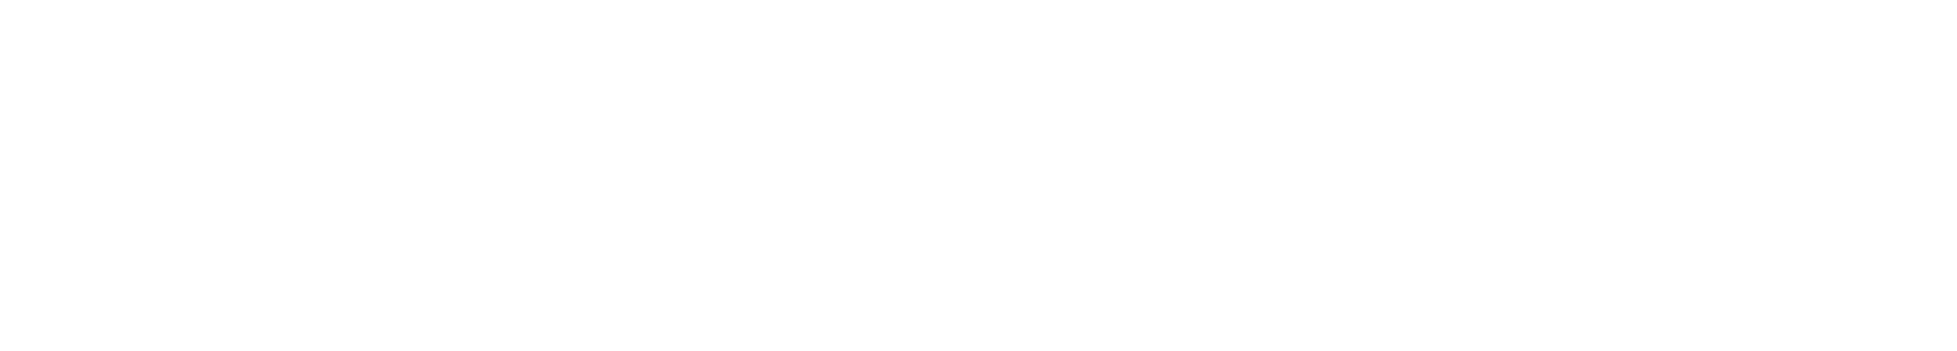

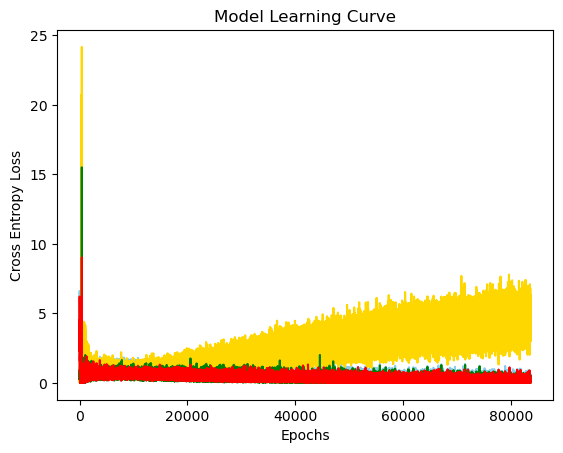

>2200, 25/38, d=0.46128410, g=4.19165468
>2201, 0/38, d=0.06670325, g=4.80273771
>2201, 25/38, d=0.18242727, g=3.25610781
>2202, 0/38, d=0.06016422, g=5.86577272
>2202, 25/38, d=0.19895084, g=2.77858639
>2203, 0/38, d=0.25487089, g=5.12761593
>2203, 25/38, d=0.18000492, g=5.22197342
>2204, 0/38, d=0.30340990, g=4.37684059
>2204, 25/38, d=0.49840891, g=3.72248030
>2205, 0/38, d=0.54602045, g=3.78862572
>2205, 25/38, d=0.15961176, g=5.42892408
>2206, 0/38, d=0.59784508, g=5.23750019
>2206, 25/38, d=0.27207342, g=3.95663404
>2207, 0/38, d=0.17653763, g=3.89882636
>2207, 25/38, d=0.16805105, g=4.55956364
>2208, 0/38, d=0.28041959, g=4.68223190
>2208, 25/38, d=0.26987660, g=4.30457973
>2209, 0/38, d=0.23199773, g=5.21339703
>2209, 25/38, d=0.39669502, g=4.88000011
>2210, 0/38, d=0.66662747, g=4.11294174
>2210, 25/38, d=0.48224604, g=2.52939415
>2211, 0/38, d=0.46198848, g=2.72611165
>2211, 25/38, d=0.40468228, g=2.71151018
>2212, 0/38, d=0.30787945, g=3.44629884
>2212, 25/38, d=0.13501374, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

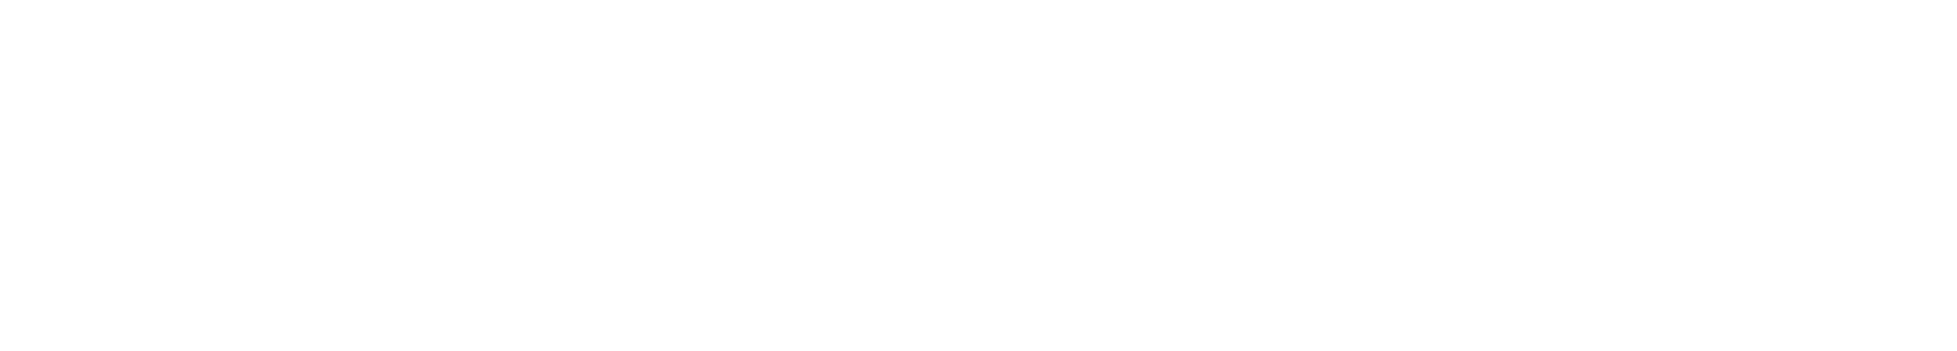

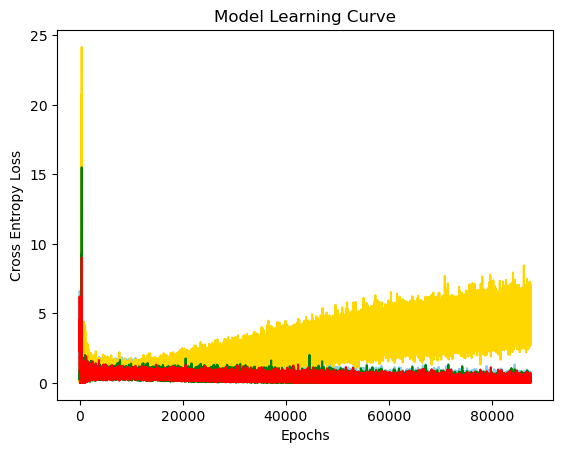

>2300, 25/38, d=0.28645772, g=5.65498257
>2301, 0/38, d=0.03654215, g=5.81412601
>2301, 25/38, d=0.74121726, g=4.46843195
>2302, 0/38, d=0.13213041, g=4.60376835
>2302, 25/38, d=0.24811496, g=4.74823380
>2303, 0/38, d=0.29234475, g=5.85872078
>2303, 25/38, d=0.55957484, g=4.18181896
>2304, 0/38, d=0.02015173, g=5.89199114
>2304, 25/38, d=0.05771635, g=5.26766300
>2305, 0/38, d=0.42545763, g=2.65879822
>2305, 25/38, d=0.48784664, g=5.54751158
>2306, 0/38, d=0.10370172, g=3.68992949
>2306, 25/38, d=0.47977513, g=6.22637129
>2307, 0/38, d=0.12272181, g=4.56878901
>2307, 25/38, d=0.17630133, g=3.97750282
>2308, 0/38, d=0.21794865, g=3.61253381
>2308, 25/38, d=0.20284972, g=5.11489820
>2309, 0/38, d=0.12857154, g=3.57448959
>2309, 25/38, d=0.08786339, g=5.81725454
>2310, 0/38, d=0.22455609, g=3.60775518
>2310, 25/38, d=0.26438719, g=3.62952948
>2311, 0/38, d=0.39037609, g=3.98107624
>2311, 25/38, d=0.43340099, g=5.78700209
>2312, 0/38, d=0.23229244, g=3.08675337
>2312, 25/38, d=0.06398925, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

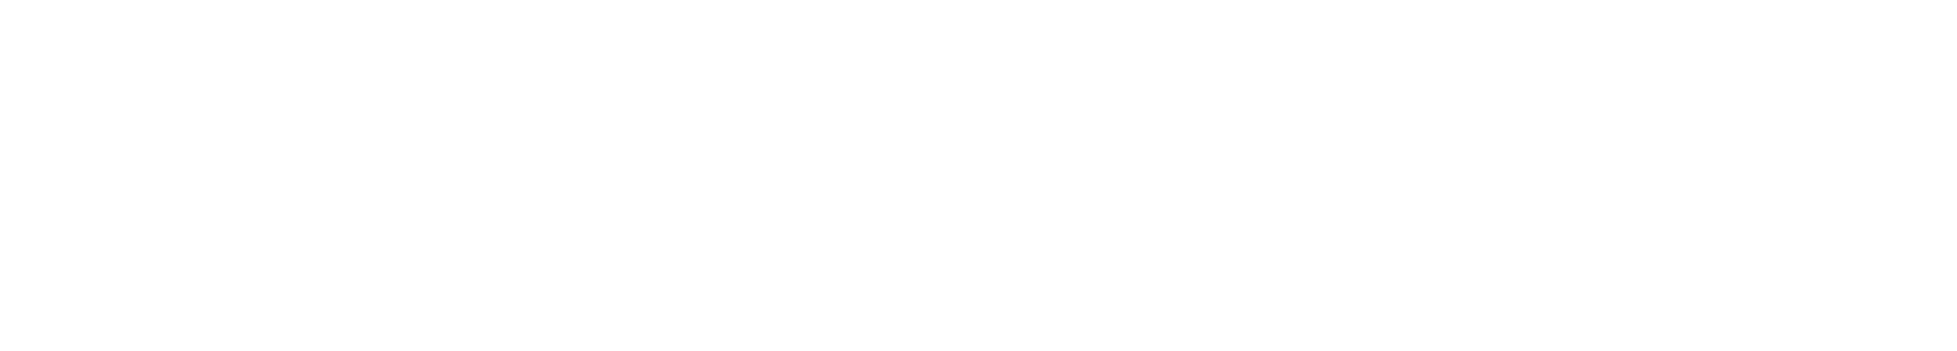

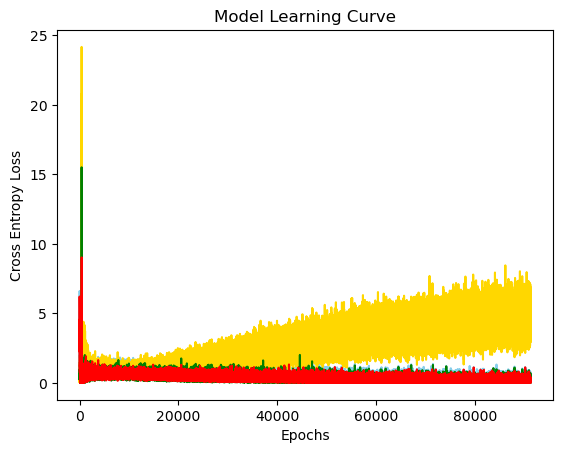

>2400, 25/38, d=0.16039358, g=7.09831476
>2401, 0/38, d=0.06703375, g=4.98141766
>2401, 25/38, d=0.12389246, g=4.71136045
>2402, 0/38, d=0.29907486, g=6.00491238
>2402, 25/38, d=0.03498177, g=5.05945206
>2403, 0/38, d=0.31895399, g=3.13921237
>2403, 25/38, d=0.29655409, g=3.32120013
>2404, 0/38, d=0.07068328, g=4.56661272
>2404, 25/38, d=0.18512116, g=4.99834251
>2405, 0/38, d=0.45112008, g=4.49062586
>2405, 25/38, d=0.20018572, g=5.51608086
>2406, 0/38, d=0.16196135, g=3.92550039
>2406, 25/38, d=0.35847127, g=4.43979454
>2407, 0/38, d=0.32052436, g=5.88018703
>2407, 25/38, d=0.10249636, g=5.24828863
>2408, 0/38, d=0.28262332, g=3.80334616
>2408, 25/38, d=0.04711617, g=6.01024294
>2409, 0/38, d=0.18050301, g=3.54766417
>2409, 25/38, d=0.27277252, g=4.21200895
>2410, 0/38, d=0.35326388, g=5.02930450
>2410, 25/38, d=0.28541735, g=4.77657223
>2411, 0/38, d=0.06049196, g=5.29878044
>2411, 25/38, d=0.22066753, g=5.65376282
>2412, 0/38, d=0.23411363, g=4.96463680
>2412, 25/38, d=0.44334435, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

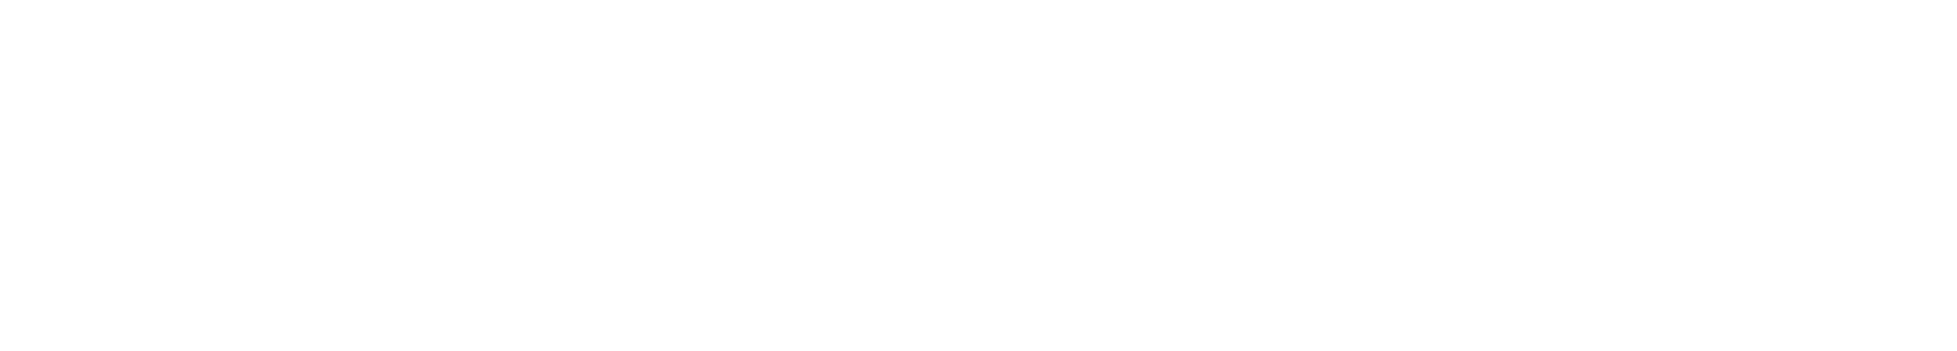

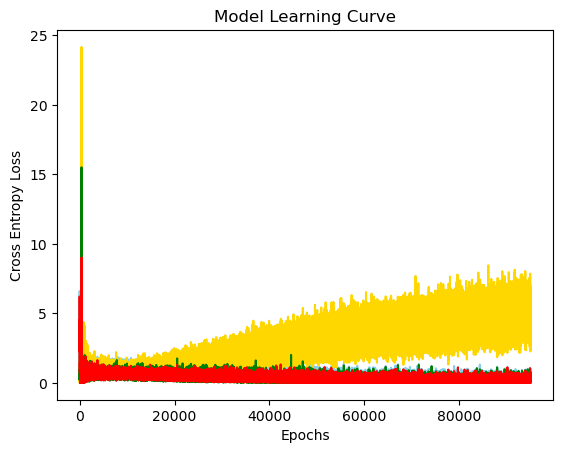

>2500, 25/38, d=0.29457894, g=3.04271269
Model Saved!
>2501, 0/38, d=0.66047657, g=3.50730133
>2501, 25/38, d=0.55768573, g=5.49668455
>2502, 0/38, d=0.16075739, g=4.22458839
>2502, 25/38, d=0.32350004, g=4.32321167
>2503, 0/38, d=0.24660353, g=7.21633625
>2503, 25/38, d=0.25161955, g=5.95263863
>2504, 0/38, d=0.11209176, g=5.61988068
>2504, 25/38, d=0.17042600, g=5.70236588
>2505, 0/38, d=0.62996721, g=3.23952198
>2505, 25/38, d=0.18498895, g=5.02067375
>2506, 0/38, d=0.12936257, g=5.06304312
>2506, 25/38, d=0.39516526, g=6.17466211
>2507, 0/38, d=0.15717472, g=5.55796528
>2507, 25/38, d=0.13592589, g=5.40604877
>2508, 0/38, d=0.44757244, g=5.09088135
>2508, 25/38, d=0.29365396, g=4.56467533
>2509, 0/38, d=0.23714308, g=6.11238575
>2509, 25/38, d=0.24595493, g=3.41726279
>2510, 0/38, d=0.15544158, g=5.94494343
>2510, 25/38, d=0.31570360, g=4.52907753
>2511, 0/38, d=0.30565909, g=5.01871872
>2511, 25/38, d=0.13949621, g=5.47381496
>2512, 0/38, d=0.31726921, g=4.07595730
>2512, 25/38, d

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

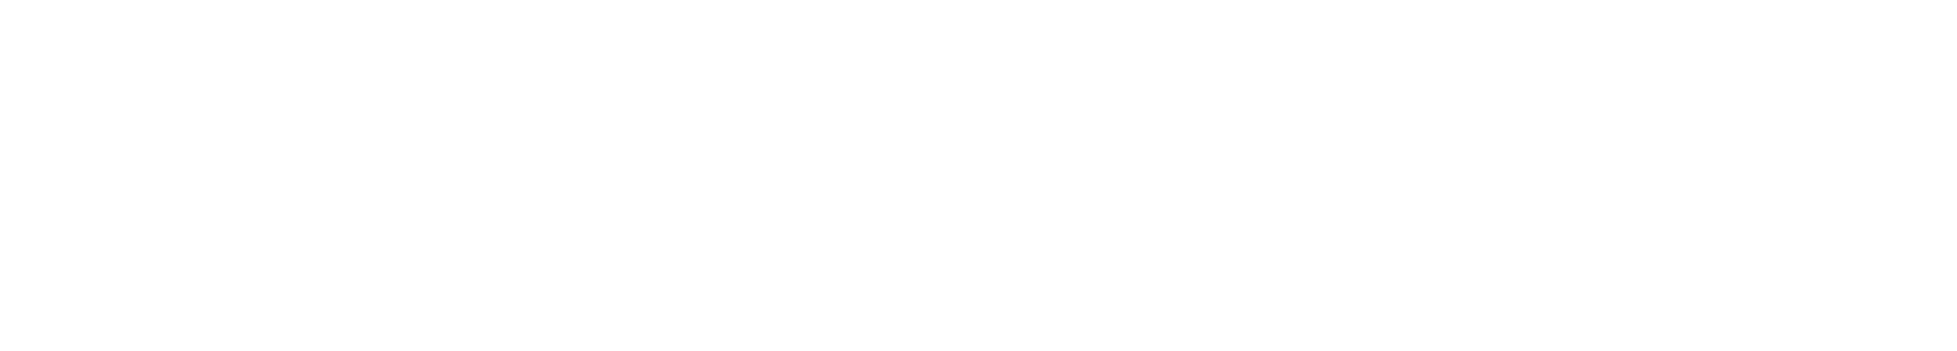

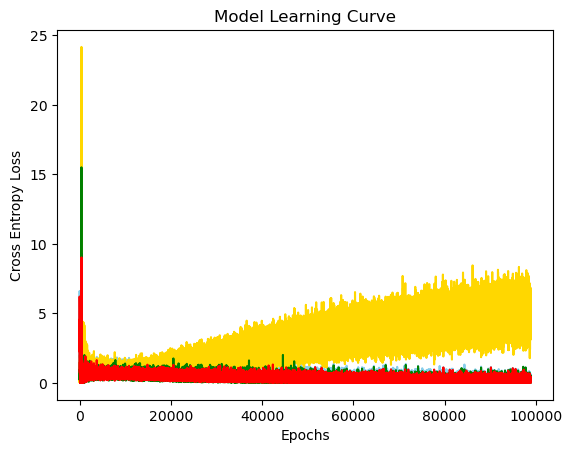

>2600, 25/38, d=0.20218360, g=3.14984083
>2601, 0/38, d=0.16588849, g=5.55533409
>2601, 25/38, d=0.16192648, g=5.63951588
>2602, 0/38, d=0.19195332, g=4.61830139
>2602, 25/38, d=0.72486913, g=3.70546055
>2603, 0/38, d=0.32918993, g=3.81889772
>2603, 25/38, d=0.32518250, g=4.18111849
>2604, 0/38, d=0.20698175, g=6.01441097
>2604, 25/38, d=0.23987305, g=4.52485609
>2605, 0/38, d=0.21017030, g=5.23599148
>2605, 25/38, d=0.47537920, g=5.00965500
>2606, 0/38, d=0.18489635, g=4.90619230
>2606, 25/38, d=0.55589628, g=3.47184420
>2607, 0/38, d=0.25826788, g=5.70579433
>2607, 25/38, d=0.44733363, g=3.20882273
>2608, 0/38, d=0.34914547, g=4.21450901
>2608, 25/38, d=0.22991893, g=4.66935730
>2609, 0/38, d=0.17334691, g=5.63628674
>2609, 25/38, d=0.29884702, g=6.25066042
>2610, 0/38, d=0.09705204, g=6.04141235
>2610, 25/38, d=0.08843666, g=4.07582474
>2611, 0/38, d=0.13170743, g=4.38764954
>2611, 25/38, d=0.11324234, g=4.86730909
>2612, 0/38, d=0.20028672, g=3.86606336
>2612, 25/38, d=0.18414529, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

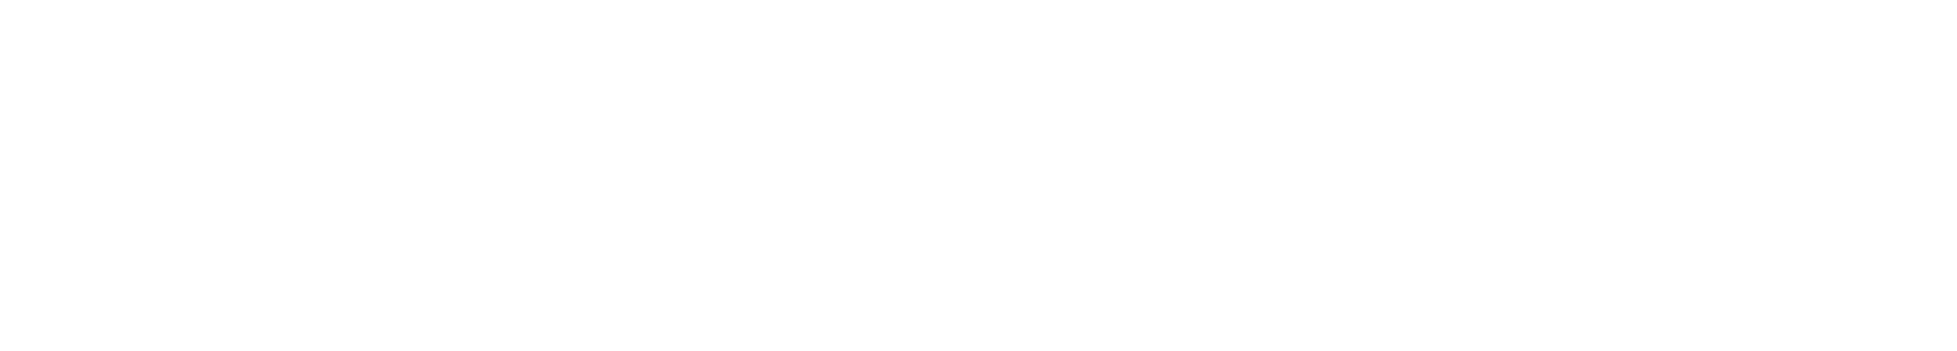

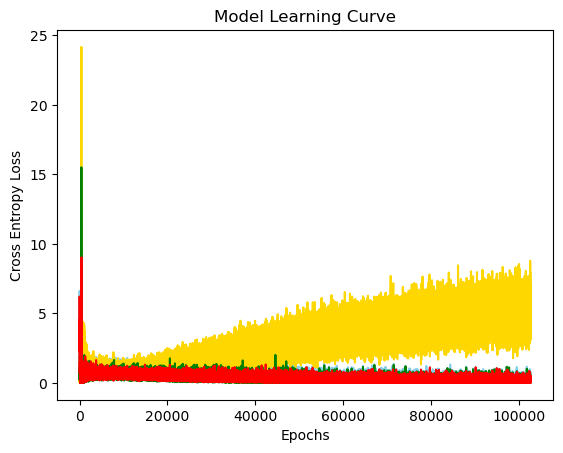

>2700, 25/38, d=0.18064764, g=5.87618542
>2701, 0/38, d=0.26486966, g=6.06173038
>2701, 25/38, d=0.40082043, g=4.60058022
>2702, 0/38, d=0.20411608, g=4.56807613
>2702, 25/38, d=0.27728030, g=3.43293595
>2703, 0/38, d=0.09960960, g=6.58433676
>2703, 25/38, d=0.25199723, g=3.49950957
>2704, 0/38, d=0.29796806, g=5.38801384
>2704, 25/38, d=0.16899930, g=4.80282688
>2705, 0/38, d=0.22960284, g=7.35481977
>2705, 25/38, d=0.03402613, g=5.52343702
>2706, 0/38, d=0.09521952, g=5.25858641
>2706, 25/38, d=0.33667004, g=5.28974819
>2707, 0/38, d=0.04545865, g=5.18047667
>2707, 25/38, d=0.03708074, g=6.41620064
>2708, 0/38, d=0.46458369, g=3.18228173
>2708, 25/38, d=0.13512641, g=4.88581896
>2709, 0/38, d=0.23968670, g=3.37711573
>2709, 25/38, d=0.69147235, g=3.97531796
>2710, 0/38, d=0.04309382, g=5.08210325
>2710, 25/38, d=0.07284750, g=5.07826233
>2711, 0/38, d=0.22706077, g=4.47107220
>2711, 25/38, d=0.35976398, g=5.17374134
>2712, 0/38, d=0.55995673, g=2.90906334
>2712, 25/38, d=0.30633530, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

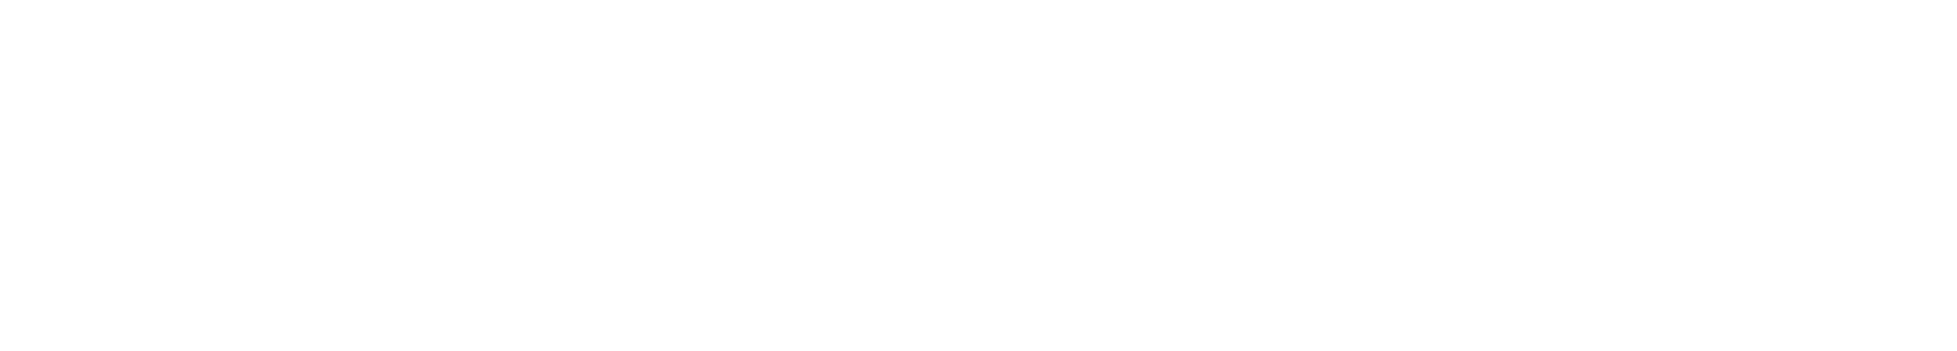

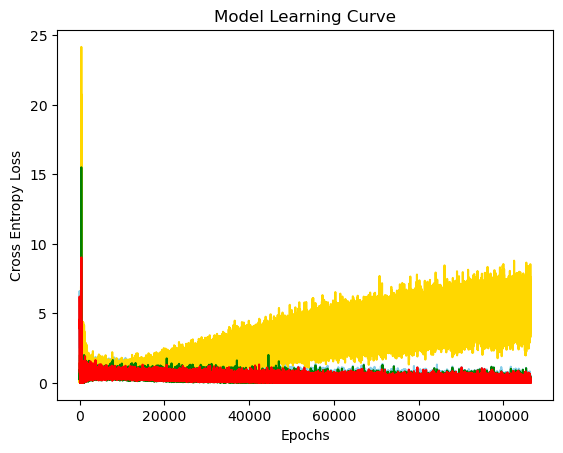

>2800, 25/38, d=0.29319599, g=4.82010365
>2801, 0/38, d=0.25459585, g=5.23442698
>2801, 25/38, d=0.25885215, g=6.14851904
>2802, 0/38, d=0.15524270, g=5.20947075
>2802, 25/38, d=0.21383752, g=4.97257519
>2803, 0/38, d=0.30573764, g=4.02729034
>2803, 25/38, d=0.13375175, g=4.08140326
>2804, 0/38, d=0.23487154, g=4.77735567
>2804, 25/38, d=0.16639996, g=4.03021908
>2805, 0/38, d=0.32595164, g=3.29709625
>2805, 25/38, d=0.36543244, g=5.35368156
>2806, 0/38, d=0.08726980, g=4.42710543
>2806, 25/38, d=0.08085826, g=4.95641708
>2807, 0/38, d=0.10512690, g=4.64529800
>2807, 25/38, d=0.44384503, g=3.75134301
>2808, 0/38, d=0.16868585, g=7.01854897
>2808, 25/38, d=0.27849624, g=4.12934303
>2809, 0/38, d=0.04818646, g=5.34188271
>2809, 25/38, d=0.07590602, g=5.57729483
>2810, 0/38, d=0.16942605, g=5.27092171
>2810, 25/38, d=0.08654339, g=6.11654806
>2811, 0/38, d=0.16525368, g=5.02232218
>2811, 25/38, d=0.12381542, g=6.06275749
>2812, 0/38, d=0.38171279, g=5.07239628
>2812, 25/38, d=0.41413894, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

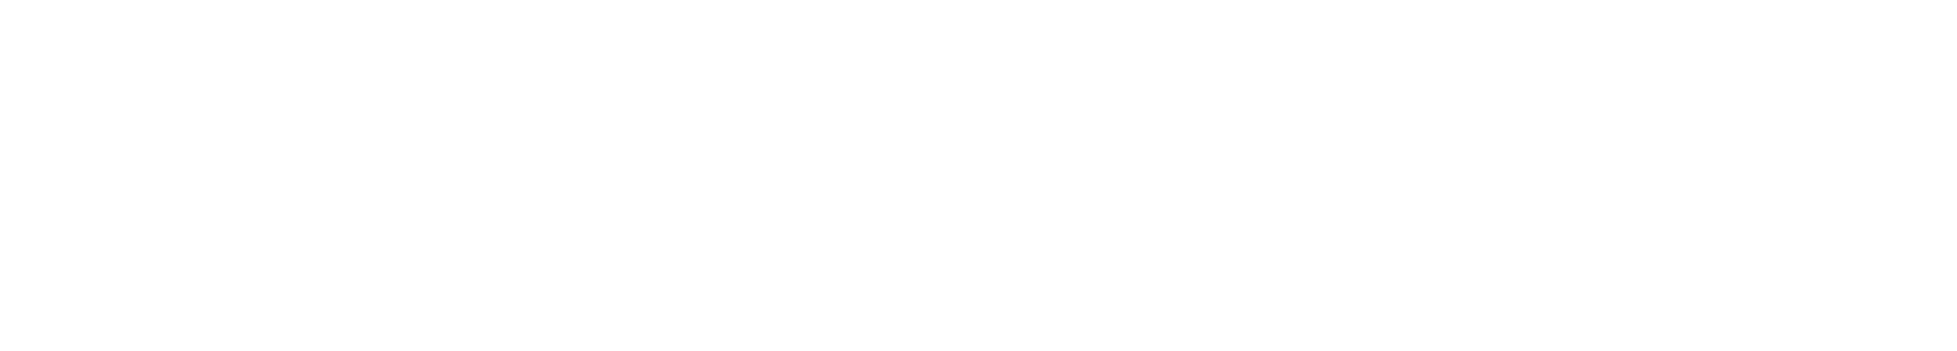

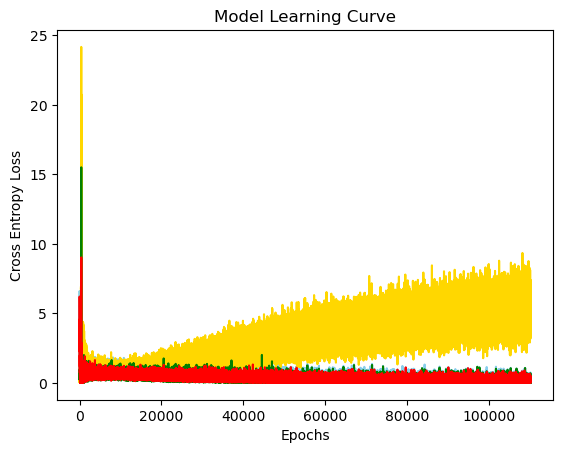

>2900, 25/38, d=0.10652485, g=5.79564285
>2901, 0/38, d=0.32022974, g=2.80098581
>2901, 25/38, d=0.22097172, g=4.81409693
>2902, 0/38, d=0.27886897, g=5.58487797
>2902, 25/38, d=0.09833555, g=5.49604416
>2903, 0/38, d=0.19045331, g=5.54977751
>2903, 25/38, d=0.12653613, g=7.23897266
>2904, 0/38, d=0.35960048, g=7.40030861
>2904, 25/38, d=0.10889821, g=5.74764061
>2905, 0/38, d=0.28862184, g=4.63731194
>2905, 25/38, d=0.10649689, g=6.25494862
>2906, 0/38, d=0.09185316, g=5.45991373
>2906, 25/38, d=0.12887363, g=5.82992792
>2907, 0/38, d=0.19407813, g=5.20437336
>2907, 25/38, d=0.17843850, g=4.25275230
>2908, 0/38, d=0.31766722, g=3.48026538
>2908, 25/38, d=0.09348218, g=6.38324213
>2909, 0/38, d=0.38127580, g=6.38720322
>2909, 25/38, d=0.18655467, g=4.36311102
>2910, 0/38, d=0.03529304, g=5.96655273
>2910, 25/38, d=0.36455360, g=5.31993771
>2911, 0/38, d=0.30930239, g=4.44974327
>2911, 25/38, d=0.17412528, g=5.92687750
>2912, 0/38, d=0.07121206, g=6.38567877
>2912, 25/38, d=0.14838247, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

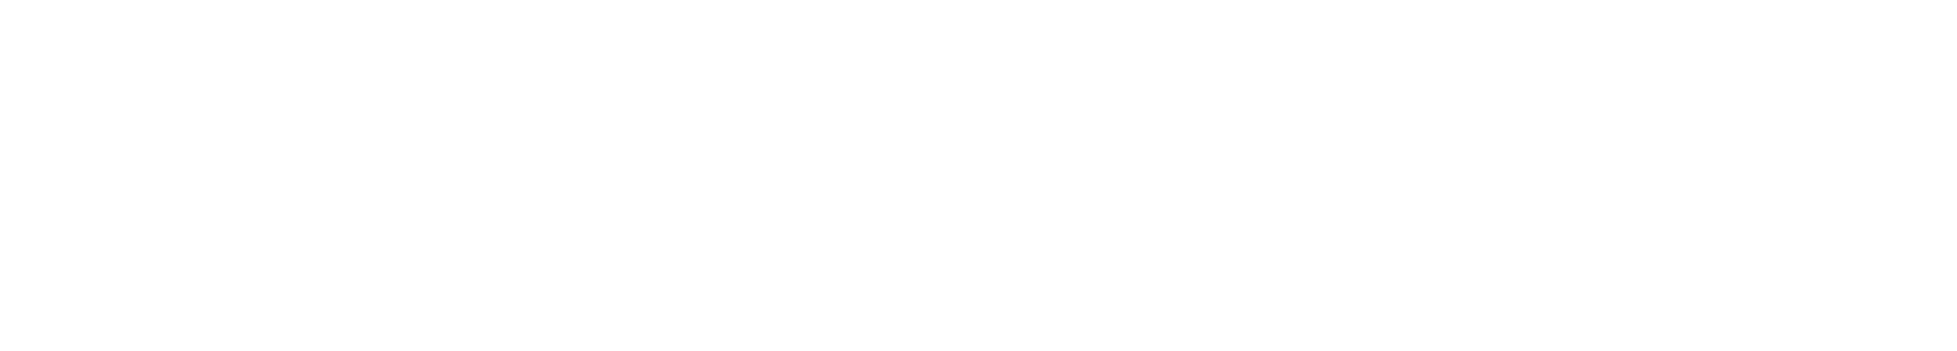

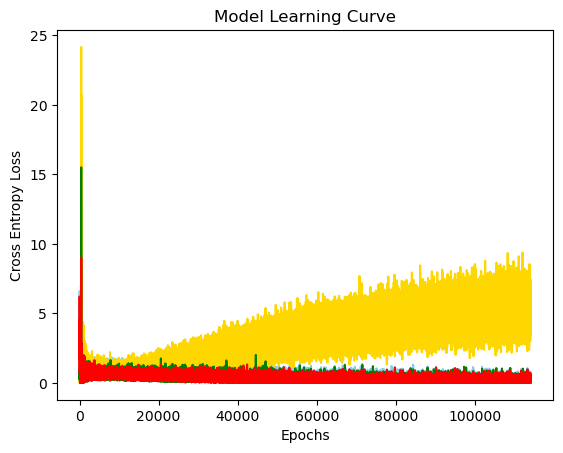

>3000, 25/38, d=0.84013438, g=2.79250050
Model Saved!
>3001, 0/38, d=0.22960521, g=6.06269646
>3001, 25/38, d=0.08686352, g=5.53634834
>3002, 0/38, d=0.20497066, g=6.38190556
>3002, 25/38, d=0.22538379, g=6.38998222
>3003, 0/38, d=0.48995596, g=4.69212532
>3003, 25/38, d=0.21441768, g=4.36040258
>3004, 0/38, d=0.12784183, g=5.25961208
>3004, 25/38, d=0.14300206, g=4.00877476
>3005, 0/38, d=0.48338419, g=5.93322086
>3005, 25/38, d=0.26536453, g=5.02281666
>3006, 0/38, d=0.11414333, g=5.49358082
>3006, 25/38, d=0.30949271, g=5.87026358
>3007, 0/38, d=0.31678915, g=4.36586952
>3007, 25/38, d=0.12286778, g=6.74417257
>3008, 0/38, d=0.40218031, g=6.86792755
>3008, 25/38, d=0.11664658, g=5.17855740
>3009, 0/38, d=0.09874554, g=6.53008747
>3009, 25/38, d=0.06509414, g=5.33858967
>3010, 0/38, d=0.14460494, g=6.17627048
>3010, 25/38, d=0.46354687, g=4.73424339
>3011, 0/38, d=0.07214101, g=5.79323101
>3011, 25/38, d=0.35394117, g=5.21815872
>3012, 0/38, d=0.15597934, g=5.42867088
>3012, 25/38, d

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

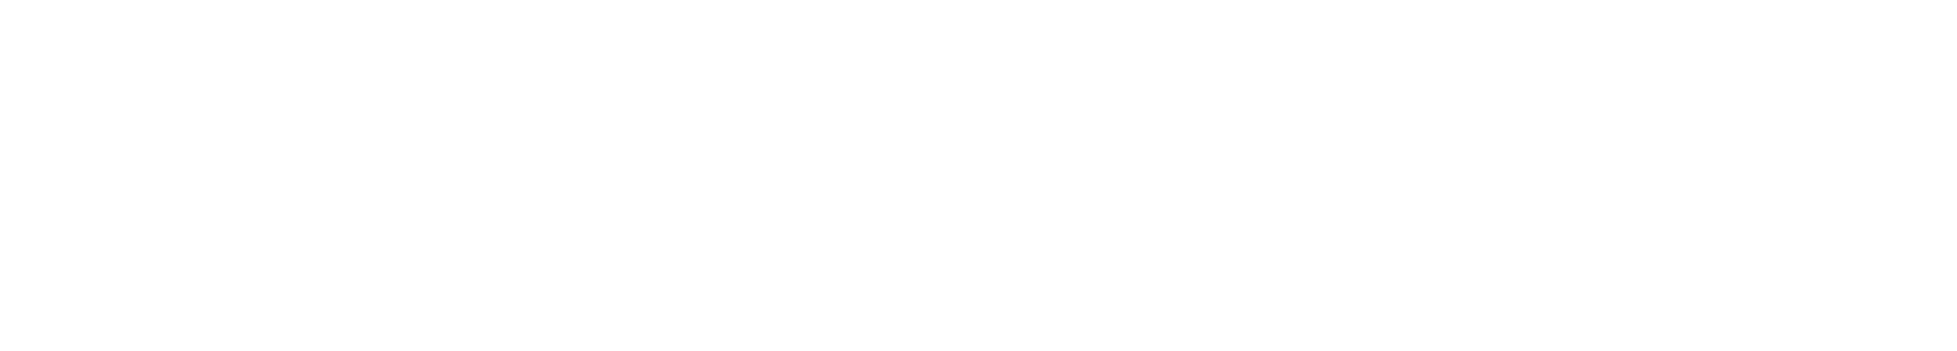

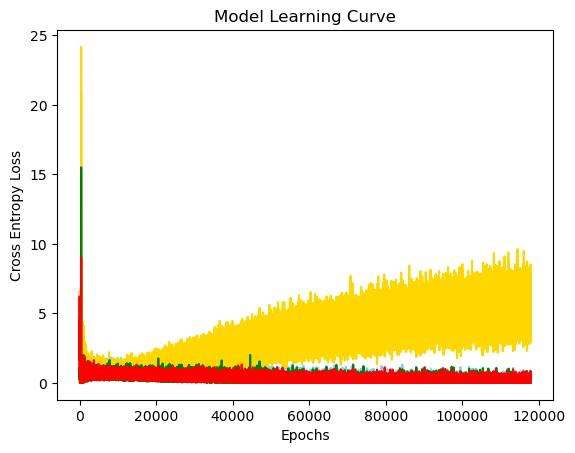

>3100, 25/38, d=0.18012133, g=4.19810820
>3101, 0/38, d=0.18842062, g=4.07558680
>3101, 25/38, d=0.12572686, g=5.55387783
>3102, 0/38, d=0.20722497, g=5.33294487
>3102, 25/38, d=0.24913205, g=7.54779196
>3103, 0/38, d=0.24281016, g=5.01377106
>3103, 25/38, d=0.34019887, g=4.34435606
>3104, 0/38, d=0.12773439, g=4.89537811
>3104, 25/38, d=0.14044672, g=6.13405800
>3105, 0/38, d=0.02555705, g=6.68335247
>3105, 25/38, d=0.06276777, g=5.80472946
>3106, 0/38, d=0.19117346, g=5.52700806
>3106, 25/38, d=0.17328586, g=4.77382088
>3107, 0/38, d=0.12995937, g=6.84731340
>3107, 25/38, d=0.55569053, g=3.39022613
>3108, 0/38, d=0.39570829, g=3.32466674
>3108, 25/38, d=0.14115742, g=4.77280712
>3109, 0/38, d=0.02787193, g=6.56487274
>3109, 25/38, d=0.10585257, g=6.67426014
>3110, 0/38, d=0.12311079, g=6.97202253
>3110, 25/38, d=0.12346954, g=3.75480485
>3111, 0/38, d=0.32540447, g=6.32922173
>3111, 25/38, d=0.05952099, g=6.74973011
>3112, 0/38, d=0.38237804, g=5.27747154
>3112, 25/38, d=0.07039936, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

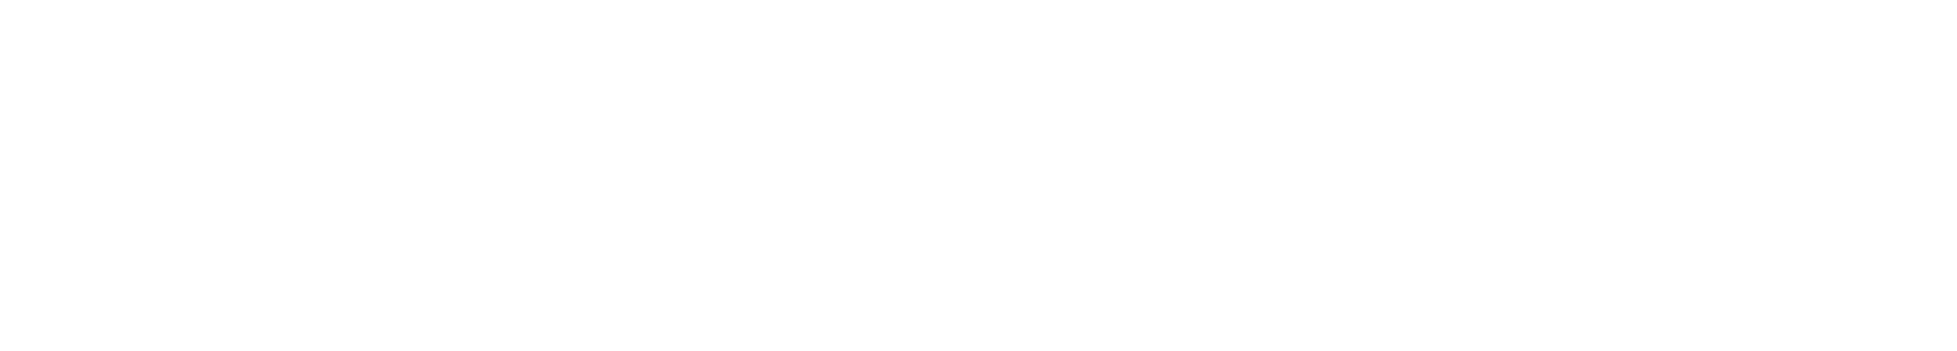

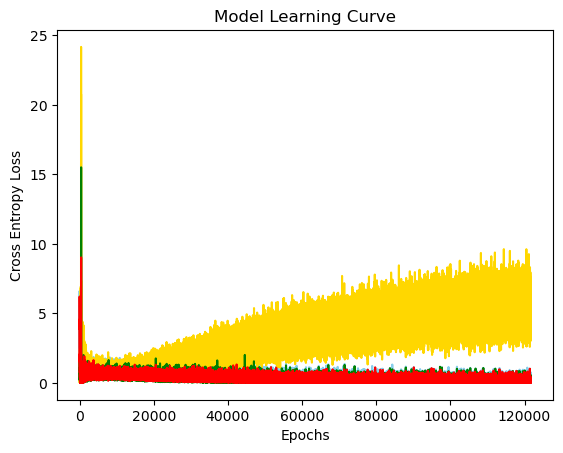

>3200, 25/38, d=0.15420744, g=3.98066282
>3201, 0/38, d=0.17088652, g=4.28827095
>3201, 25/38, d=0.07757393, g=4.78719616
>3202, 0/38, d=0.28182152, g=6.13942385
>3202, 25/38, d=0.10334337, g=5.29913998
>3203, 0/38, d=0.23153697, g=6.40252876
>3203, 25/38, d=0.44824371, g=5.77918530
>3204, 0/38, d=0.16578037, g=4.77164030
>3204, 25/38, d=0.23911364, g=4.36349773
>3205, 0/38, d=0.32288513, g=6.26426888
>3205, 25/38, d=0.14154521, g=5.39488077
>3206, 0/38, d=0.15847811, g=5.28528214
>3206, 25/38, d=0.11841884, g=5.29302692
>3207, 0/38, d=0.03417021, g=5.44072151
>3207, 25/38, d=0.33476323, g=4.45932388
>3208, 0/38, d=0.13528764, g=6.77646971
>3208, 25/38, d=0.63367152, g=5.46885300
>3209, 0/38, d=0.17328146, g=5.46312380
>3209, 25/38, d=0.24838684, g=5.64397001
>3210, 0/38, d=0.40761730, g=4.05014133
>3210, 25/38, d=0.08057737, g=4.56600571
>3211, 0/38, d=0.10699071, g=4.82333279
>3211, 25/38, d=0.06650080, g=5.72163486
>3212, 0/38, d=0.30871749, g=3.75628328
>3212, 25/38, d=0.41595051, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

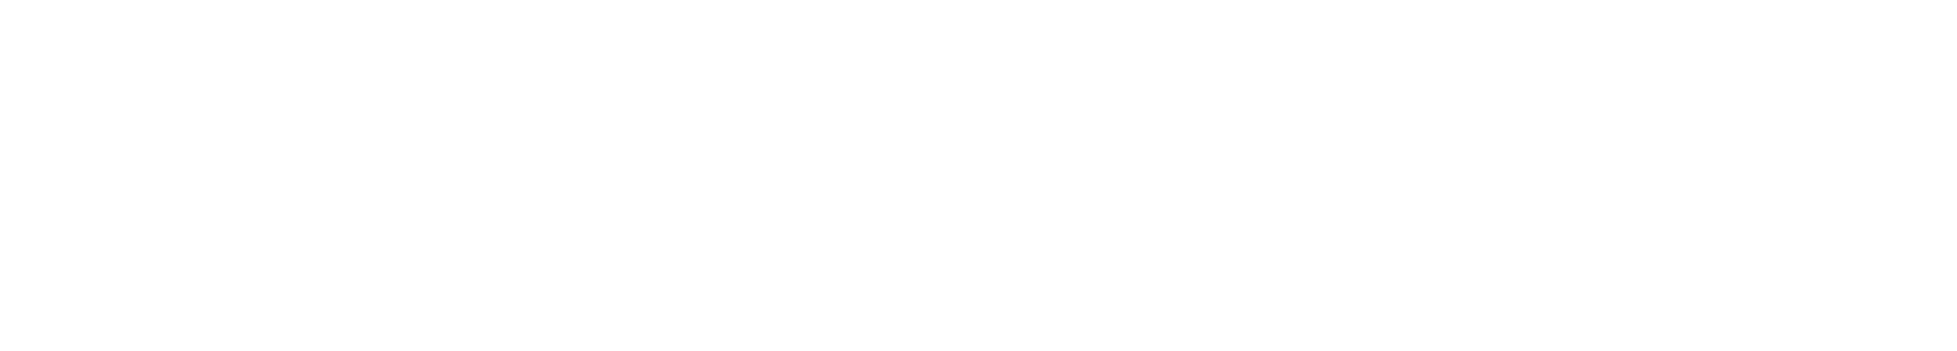

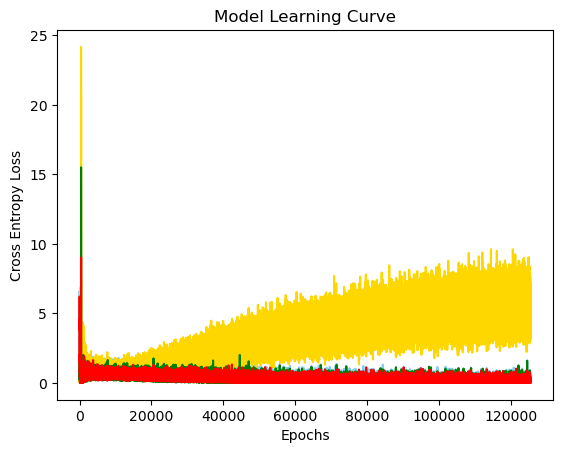

>3300, 25/38, d=0.29023466, g=5.74126720
>3301, 0/38, d=0.18539946, g=5.43611097
>3301, 25/38, d=0.11194352, g=5.54813480
>3302, 0/38, d=0.13219810, g=4.88890934
>3302, 25/38, d=0.31886938, g=4.82417679
>3303, 0/38, d=0.47514340, g=4.91364717
>3303, 25/38, d=0.29597116, g=6.58775949
>3304, 0/38, d=0.59771281, g=6.67197609
>3304, 25/38, d=0.08306263, g=7.47103691
>3305, 0/38, d=0.57314295, g=5.35673666
>3305, 25/38, d=0.09424581, g=4.58560753
>3306, 0/38, d=0.13794202, g=6.34946775
>3306, 25/38, d=0.28912151, g=3.48270249
>3307, 0/38, d=0.14673704, g=5.32223129
>3307, 25/38, d=0.07065715, g=6.50179672
>3308, 0/38, d=0.07330548, g=5.11929417
>3308, 25/38, d=0.27290878, g=4.90459538
>3309, 0/38, d=0.07947873, g=6.40290117
>3309, 25/38, d=0.29449075, g=4.34812641
>3310, 0/38, d=0.26361793, g=7.24164677
>3310, 25/38, d=0.18197109, g=4.08950949
>3311, 0/38, d=0.20339724, g=6.16296721
>3311, 25/38, d=0.17157000, g=5.82564259
>3312, 0/38, d=0.34380031, g=4.45328665
>3312, 25/38, d=0.03471544, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

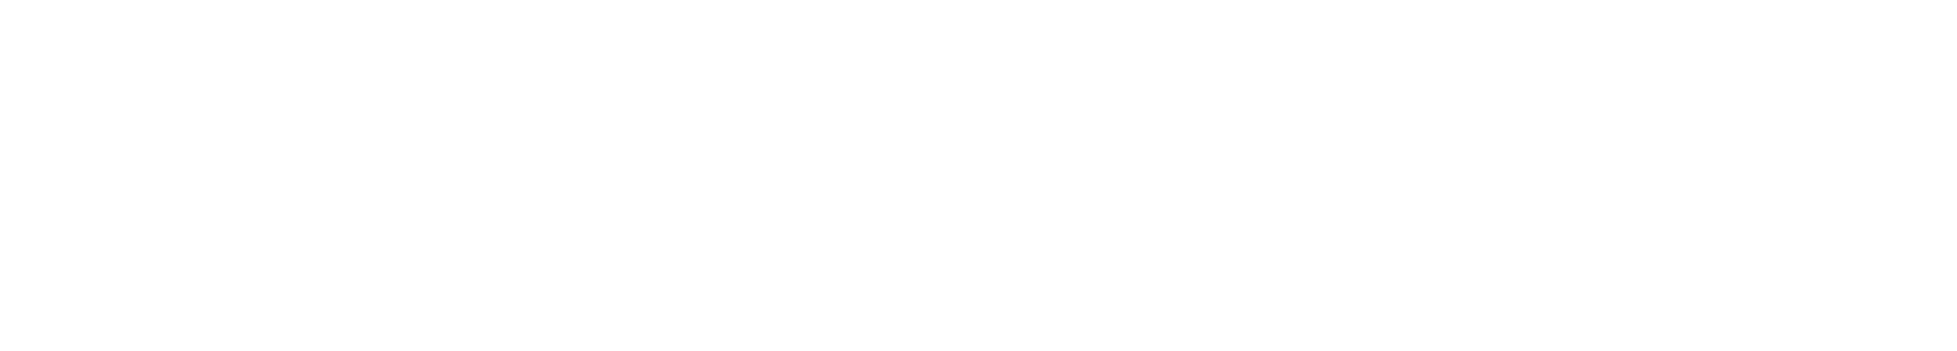

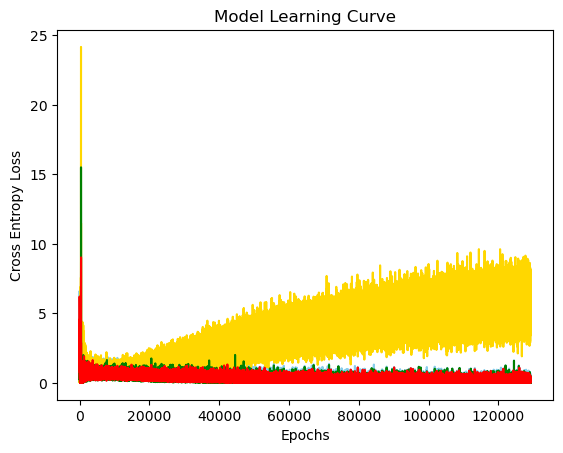

>3400, 25/38, d=0.05307492, g=5.70786190
>3401, 0/38, d=0.18960768, g=5.75454617
>3401, 25/38, d=0.46865621, g=5.45895958
>3402, 0/38, d=0.12436176, g=7.07099628
>3402, 25/38, d=0.10551597, g=6.77364445
>3403, 0/38, d=0.16595285, g=5.94635391
>3403, 25/38, d=0.07728548, g=7.30722332
>3404, 0/38, d=0.20393504, g=3.86249185
>3404, 25/38, d=0.07765609, g=8.09349632
>3405, 0/38, d=0.20470664, g=5.32031298
>3405, 25/38, d=0.07269780, g=6.60080147
>3406, 0/38, d=0.44503376, g=5.58763790
>3406, 25/38, d=0.20551971, g=4.20961380
>3407, 0/38, d=0.08884141, g=7.05046749
>3407, 25/38, d=0.08578712, g=5.76360703
>3408, 0/38, d=0.20569940, g=6.24925423
>3408, 25/38, d=0.15491909, g=5.45327473
>3409, 0/38, d=0.30257520, g=4.90429306
>3409, 25/38, d=0.08720350, g=6.20894623
>3410, 0/38, d=0.30215484, g=5.49389648
>3410, 25/38, d=0.04468873, g=6.19101524
>3411, 0/38, d=0.03761420, g=5.42824173
>3411, 25/38, d=0.08491297, g=5.24206066
>3412, 0/38, d=0.08506498, g=5.12782860
>3412, 25/38, d=0.07470939, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

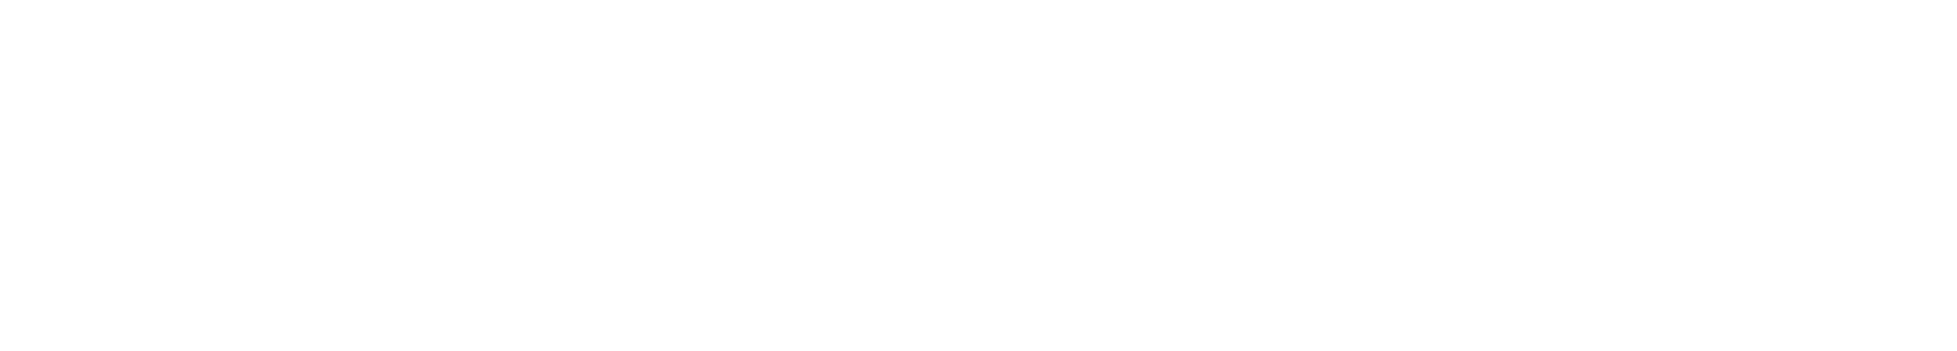

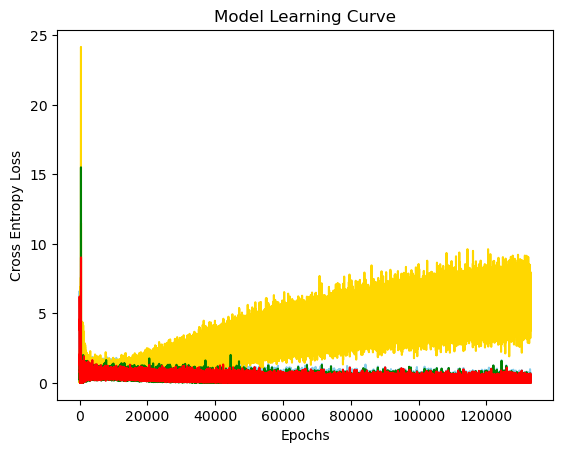

>3500, 25/38, d=0.01490062, g=7.81590271
Model Saved!
>3501, 0/38, d=0.05265609, g=7.73419666
>3501, 25/38, d=0.30395335, g=4.47835255
>3502, 0/38, d=0.41772267, g=4.78288651
>3502, 25/38, d=0.22174613, g=5.82675457
>3503, 0/38, d=0.14404891, g=6.27483606
>3503, 25/38, d=0.10492952, g=4.93236923
>3504, 0/38, d=0.04412646, g=5.37780142
>3504, 25/38, d=0.18517289, g=6.16386604
>3505, 0/38, d=0.49158898, g=4.29083681
>3505, 25/38, d=0.21059959, g=5.24322939
>3506, 0/38, d=0.29413986, g=4.56735134
>3506, 25/38, d=0.16399339, g=6.02670860
>3507, 0/38, d=0.12551473, g=6.02511597
>3507, 25/38, d=0.06177286, g=5.62381363
>3508, 0/38, d=0.26199117, g=3.52938819
>3508, 25/38, d=0.29799834, g=5.70662355
>3509, 0/38, d=0.62513500, g=8.14337158
>3509, 25/38, d=0.12663169, g=5.43845081
>3510, 0/38, d=0.02103852, g=5.98019361
>3510, 25/38, d=0.06430087, g=6.09310532
>3511, 0/38, d=0.06608002, g=5.60337877
>3511, 25/38, d=0.06993239, g=6.30370331
>3512, 0/38, d=0.28596747, g=6.05808449
>3512, 25/38, d

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

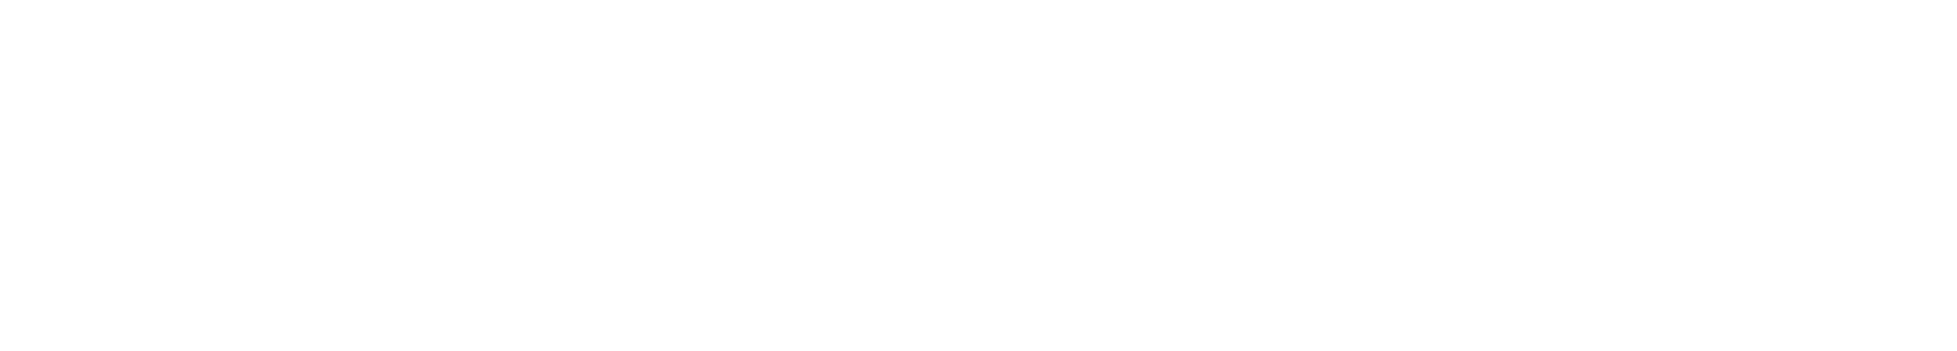

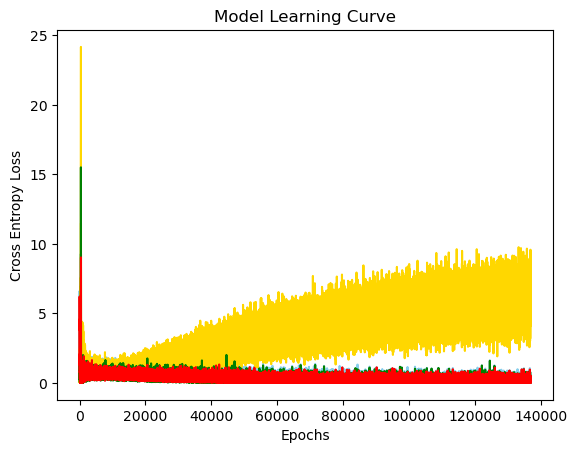

>3600, 25/38, d=0.09001551, g=5.62709141
>3601, 0/38, d=0.01646999, g=6.58649445
>3601, 25/38, d=0.23830691, g=7.03786135
>3602, 0/38, d=0.33712357, g=4.10195923
>3602, 25/38, d=0.18644831, g=5.76346445
>3603, 0/38, d=0.39958283, g=6.13877010
>3603, 25/38, d=0.19457057, g=6.64692354
>3604, 0/38, d=0.13624820, g=5.35781097
>3604, 25/38, d=0.21271327, g=4.84545517
>3605, 0/38, d=0.35070655, g=4.49699640
>3605, 25/38, d=0.31991136, g=6.79185247
>3606, 0/38, d=0.24721611, g=4.92741823
>3606, 25/38, d=0.15061048, g=5.22881413
>3607, 0/38, d=0.03418301, g=6.20394897
>3607, 25/38, d=0.12089445, g=6.58756065
>3608, 0/38, d=0.01673070, g=6.75697947
>3608, 25/38, d=0.11265486, g=5.94432449
>3609, 0/38, d=0.20422164, g=6.51344252
>3609, 25/38, d=0.04495526, g=6.93724632
>3610, 0/38, d=0.10714458, g=5.50991678
>3610, 25/38, d=0.19530067, g=5.23694992
>3611, 0/38, d=0.20564471, g=6.92912388
>3611, 25/38, d=0.07726423, g=5.56056404
>3612, 0/38, d=0.28594252, g=4.81759262
>3612, 25/38, d=0.38194281, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

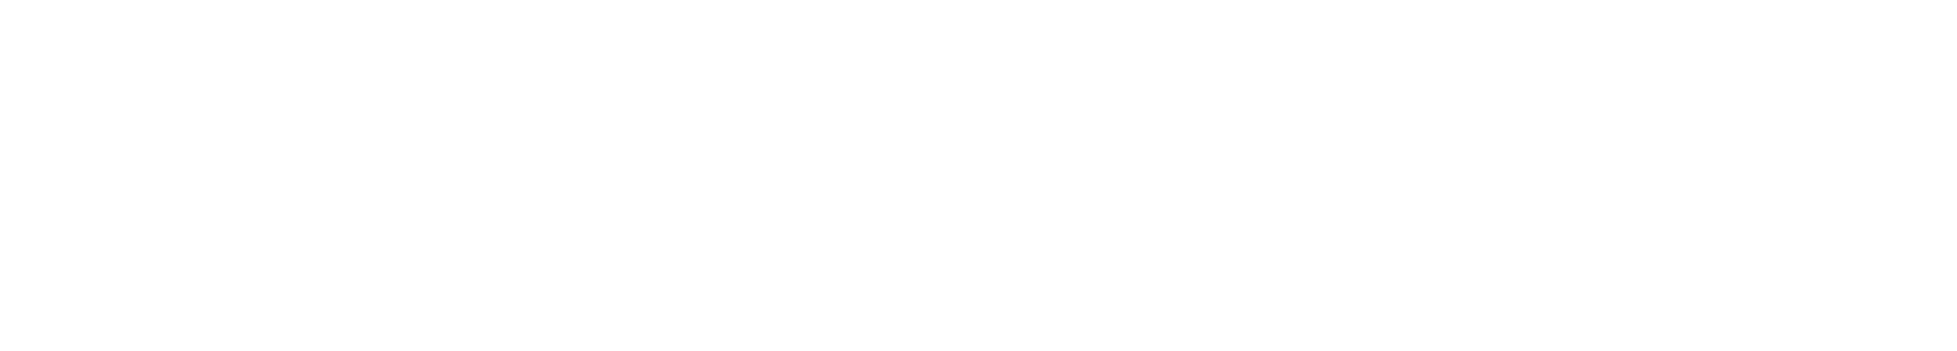

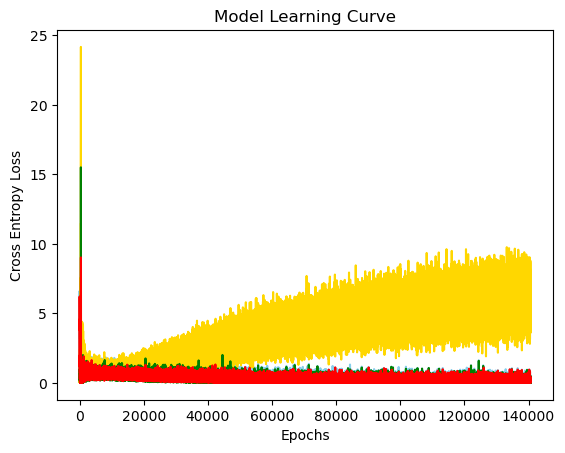

>3700, 25/38, d=0.13855350, g=6.12976885
>3701, 0/38, d=0.13728394, g=6.23926735
>3701, 25/38, d=0.12292215, g=6.88011312
>3702, 0/38, d=0.20825931, g=6.56518078
>3702, 25/38, d=0.25098491, g=5.37678814
>3703, 0/38, d=0.09917852, g=5.61588812
>3703, 25/38, d=0.27115726, g=6.01172161
>3704, 0/38, d=0.15401912, g=5.47781849
>3704, 25/38, d=0.72987479, g=5.34414196
>3705, 0/38, d=0.11932351, g=7.32213497
>3705, 25/38, d=0.19444969, g=6.34486198
>3706, 0/38, d=0.21045017, g=5.09673119
>3706, 25/38, d=0.05628753, g=8.13809776
>3707, 0/38, d=0.27379063, g=6.00659657
>3707, 25/38, d=0.05662832, g=7.92117596
>3708, 0/38, d=0.12493519, g=5.17226410
>3708, 25/38, d=0.01970919, g=6.49737263
>3709, 0/38, d=0.08434004, g=5.65161657
>3709, 25/38, d=0.28491682, g=5.80508947
>3710, 0/38, d=0.11982167, g=6.91288376
>3710, 25/38, d=0.31619883, g=4.76896572
>3711, 0/38, d=0.01420912, g=6.53979683
>3711, 25/38, d=0.13109751, g=6.42152977
>3712, 0/38, d=0.06207050, g=6.79162025
>3712, 25/38, d=0.09758091, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

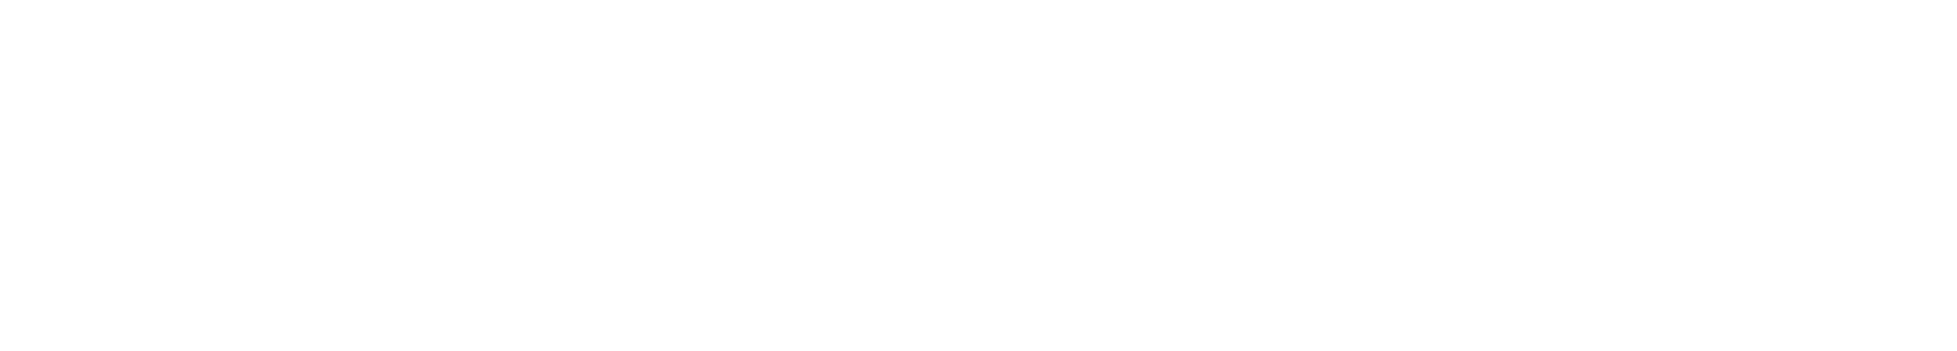

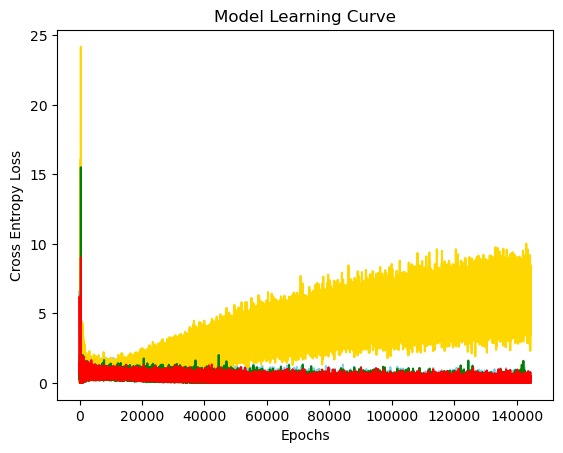

>3800, 25/38, d=0.36457711, g=5.44375324
>3801, 0/38, d=0.12800109, g=5.80412483
>3801, 25/38, d=0.22156486, g=6.32263374
>3802, 0/38, d=0.14085709, g=6.20684433
>3802, 25/38, d=0.14061075, g=5.04311085
>3803, 0/38, d=0.19642967, g=4.39186335
>3803, 25/38, d=0.25410223, g=6.86497307
>3804, 0/38, d=0.24832769, g=6.66939640
>3804, 25/38, d=0.14491706, g=6.00711632
>3805, 0/38, d=0.13050446, g=6.57819080
>3805, 25/38, d=0.14622697, g=5.87605000
>3806, 0/38, d=0.23350824, g=5.00676155
>3806, 25/38, d=0.53044283, g=4.92467499
>3807, 0/38, d=0.07035013, g=7.43680096
>3807, 25/38, d=0.24832386, g=4.47510719
>3808, 0/38, d=0.23503429, g=3.52179098
>3808, 25/38, d=0.14746030, g=5.11727238
>3809, 0/38, d=0.16363275, g=4.41669178
>3809, 25/38, d=0.17034334, g=7.02659178
>3810, 0/38, d=0.17840816, g=8.13199806
>3810, 25/38, d=0.17204763, g=4.42868137
>3811, 0/38, d=0.14966834, g=7.82299709
>3811, 25/38, d=0.16648577, g=4.29045200
>3812, 0/38, d=0.37264702, g=3.64136338
>3812, 25/38, d=0.05654822, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

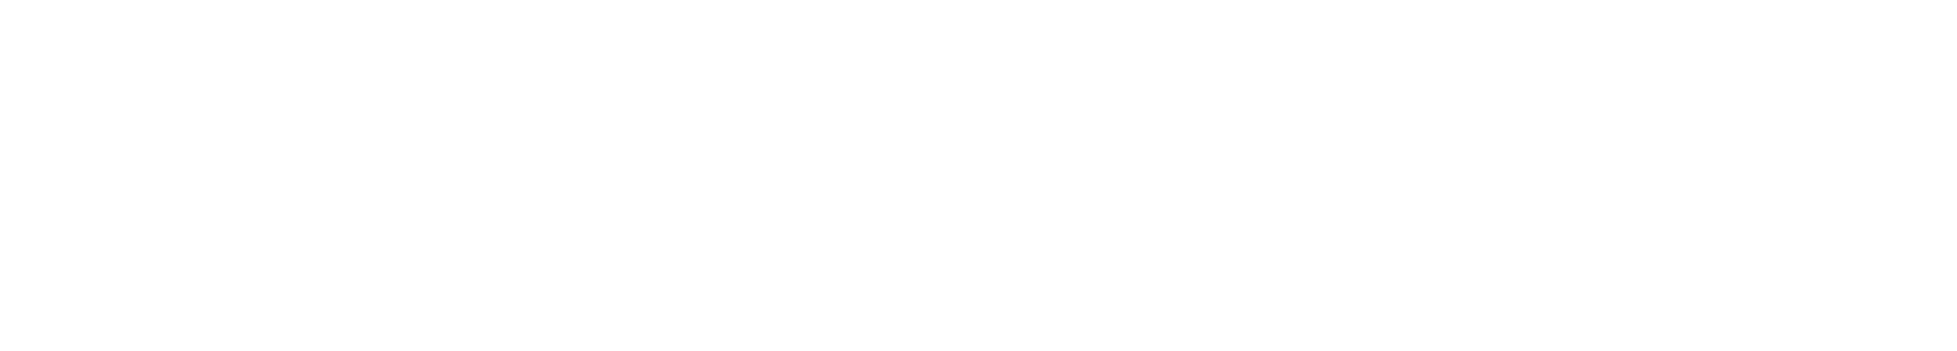

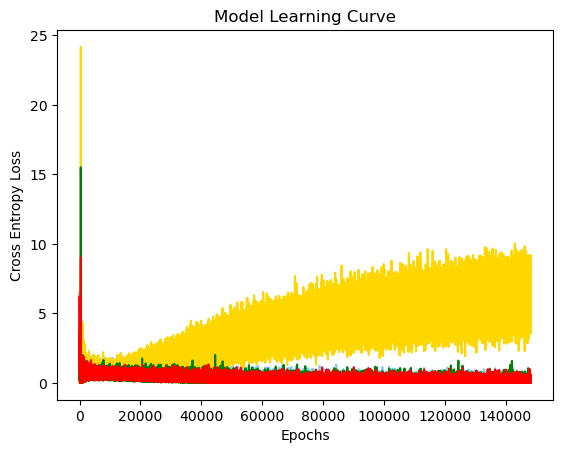

>3900, 25/38, d=0.17993279, g=6.35838223
>3901, 0/38, d=0.09676598, g=7.80179739
>3901, 25/38, d=0.17273602, g=5.08597088
>3902, 0/38, d=0.20562734, g=4.98746920
>3902, 25/38, d=0.10083798, g=7.16344166
>3903, 0/38, d=0.12533092, g=6.00776100
>3903, 25/38, d=0.08834830, g=6.68677425
>3904, 0/38, d=0.19449160, g=6.19100952
>3904, 25/38, d=0.04407805, g=8.41330147
>3905, 0/38, d=0.08251309, g=6.06552172
>3905, 25/38, d=0.47725201, g=4.08616257
>3906, 0/38, d=0.08525596, g=7.75877666
>3906, 25/38, d=0.36171520, g=5.13061905
>3907, 0/38, d=0.01482824, g=7.73844290
>3907, 25/38, d=0.04712804, g=6.53969049
>3908, 0/38, d=0.20335637, g=5.62617970
>3908, 25/38, d=0.12315136, g=4.84706783
>3909, 0/38, d=0.04499640, g=6.39631367
>3909, 25/38, d=0.04459885, g=6.16208935
>3910, 0/38, d=0.07731272, g=6.43619871
>3910, 25/38, d=0.04797880, g=5.66607952
>3911, 0/38, d=0.34637079, g=6.95745134
>3911, 25/38, d=0.18826587, g=8.16437149
>3912, 0/38, d=0.09143025, g=4.09858561
>3912, 25/38, d=0.05284290, 

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

...

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

<Figure size 2500x2500 with 0 Axes>

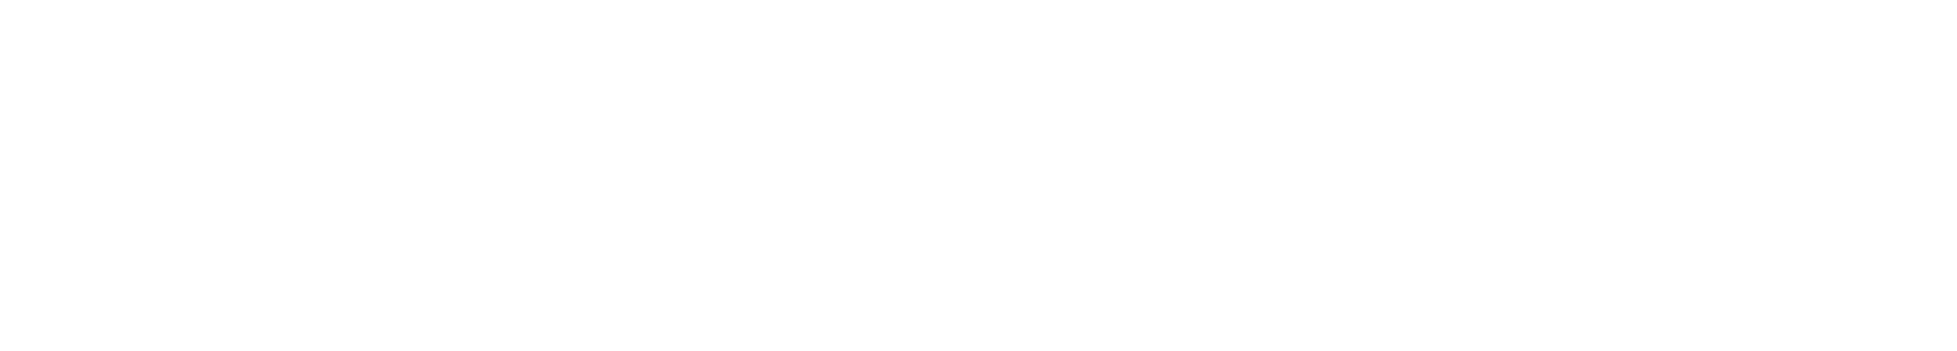

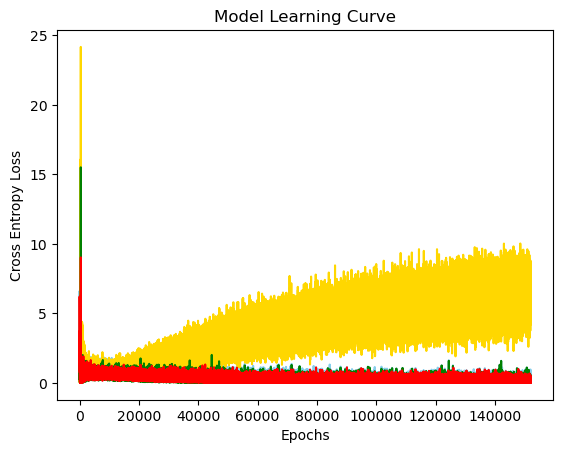

>4000, 25/38, d=0.78839999, g=4.85605717
Model Saved!
>4001, 0/38, d=0.01531779, g=6.74120808
>4001, 25/38, d=0.37213531, g=6.31079769


ValueError: too many values to unpack (expected 4)

<Figure size 2500x2500 with 0 Axes>

In [19]:
d_hist, g_hist, g_model, saved_checkpoint = train(train_dataset, EPOCHS)

In [ ]:
# from matplotlib import pyplot as plt
# def plot_learning_curve(d_loss_lst, gan_loss_lst):
#   fig = plt.figure()
#   plt.plot(d_loss_lst, color='skyblue')
#   plt.plot(gan_loss_lst, color='gold')
#   plt.title('Model Learning Curve')
#   plt.xlabel('Epochs'); plt.ylabel('Cross Entropy Loss')
#   plt.savefig('/kaggle/working/Learning Curves.png')

#   plt.show()

In [ ]:
# plot_learning_curve(d_hist, g_hist)

In [ ]:
# checkpoint_filepath = '/kaggle/input/ckpt-08-03/'
# # checkpoint_filepath = '/kaggle/input/ckpt-index-45/ckpt-45.index'
# generator_mode_instance.load_weights(checkpoint_filepath)
# generator_mode_instance.summmary()

In [ ]:
# #######look at generator images########
# # n_samples=5
# noise = tf.random.normal([DISPLAY_SAMPLES, LATENT_DIM])
# x_fake = g_model(noise,training=False)

# pyplot.figure(figsize=(25,25))
# for i in range(DISPLAY_SAMPLES):
#     # define subplot
#     pyplot.subplot(5, 5, 1 + i)
#     pyplot.axis('off')
#     # plot single image
#     pyplot.imshow(x_fake[i, :, :,0],cmap='gray')
# pyplot.show()
# pyplot.close()

In [ ]:
# #since calculating SSIM for one image is computationally expensive, just choose the index of one image to calculate
# #whichfake is the index of the sample image
# whichfake=4

# #create array to store SSIM values
# ssim_noise=[]

# #calculate SSIM for each training image
# for i in range(images.shape[0]):
#     ssim_noise.append( ssim(images[i,:,:,0], x_fake.numpy()[whichfake,:,:,0], 
#                       data_range=np.max(x_fake.numpy()[whichfake,:,:,0]) - np.min(x_fake.numpy()[whichfake,:,:,0])))

# #plot generated image and OASIS image that corresponds to the highest SSIM value
# fig, axs = pyplot.subplots(2, 1, constrained_layout=True,figsize=(10,10))
# axs[0].imshow(x_fake[whichfake, :, :, 0],cmap="gray")
# axs[0].set_title('Generated image with max SSIM: {:.4f}'.format(np.max(ssim_noise)))
# pyplot.savefig('/kaggle/working/Generated {}.png'.format(np.max(ssim_noise)))
# print("Generated image SSIM: ", np.max(ssim_noise))

# axs[1].imshow(images[ssim_noise.index(np.max(ssim_noise)), :, :, 0],cmap="gray")
# axs[1].set_title('Closest Pituitary image {:.0f}'.format(ssim_noise.index(np.max(ssim_noise))))
# pyplot.savefig('/kaggle/working/Closest Pituitary image {}.png'.format(np.max(ssim_noise)))
# print("Closest image SSIM: ", np.max(ssim_noise))
# pyplot.show()